The goal of this notebook is to implement Shor's algorithm and then transpile into an MQBC pattern. We will first explain how the algorithm is implement in the circuit based case. Then we will transpile it. In this notebook we are not creating the database we used for our simulation.

# Shor's Algorithm — MBQC Graph State Generation with Graphix

## Overview

Shor's algorithm efficiently factors a composite integer $N$ on a quantum computer.
Given a randomly chosen $a$ coprime to $N$, it finds the **order** $r$ of $a$ modulo $N$
(i.e. the smallest positive integer $r$ such that $a^r \equiv 1 \pmod{N}$), from which
non-trivial factors of $N$ can be extracted classically.

## Circuit structure

The quantum circuit for Shor's algorithm uses two registers:

| Register | Size | Purpose |
|---|---|---|
| **Counting register** | $n = \lceil \log_2 N \rceil$ qubits (or $2n$ for higher success probability) | Stores the superposition for the QFT and then measured at the end |
| **Work register** | $n = \lceil \log_2 N \rceil$ qubits | Stores the modular exponentiation result |

### Step-by-step circuit

1. **Initialize**: all qubits start in $|0\rangle$.
2. **Hadamard on counting register**: puts the first register into an equal superposition
   $$\frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle |0\rangle$$
3. **Controlled modular exponentiation**: applies the unitary
   $$U_a |x\rangle|y\rangle = |x\rangle |y \cdot a^x \bmod N\rangle$$
   This is decomposed into a sequence of **controlled modular multiplications**
   $U_{a^{2^j}}$ controlled by each qubit $j$ in the counting register. Each such multiplication is further broken into:
   - Controlled modular additions
   - Controlled swaps
   - Reversible comparators
   
   All of these are built from **Toffoli (CCX)**, **CNOT**, and single-qubit gates.

4. **Inverse Quantum Fourier Transform (QFT$^\dagger$)** on the counting register:
   $$\text{QFT}^\dagger = \prod \text{H} \cdot \prod \text{CPhase}(2\pi/2^k)$$
   Since graphix has no native controlled-phase gate, we decompose each $CR_k$ as:
   $$CR_k = \text{CNOT} \cdot R_z(\theta/2) \cdot \text{CNOT} \cdot R_z(-\theta/2)$$
   where $\theta = 2\pi / 2^k$.

5. **Measure** the counting register and classically post-process with continued fractions.

### Gate decompositions for graphix

Graphix v0.3.2 supports: `h`, `x`, `y`, `z`, `s`, `rx`, `ry`, `rz`, `cnot`, `ccx` (Toffoli), `swap`, and `rzz`.

Key decompositions we use:
- **Controlled-Phase $CR_k(\theta)$** → `cnot` + `rz` (2 CNOTs + 2 Rz rotations)
- **Controlled-SWAP (Fredkin)** → 2 `cnot` + 1 `ccx`  
- **Modular exponentiation** → for the pedagogical examples ($N = 15, 21$), we hard-code
  efficient oracle circuits that implement $a^x \bmod N$ using only CNOT, Toffoli, and SWAP gates.

## 1. Imports

In [1]:
from __future__ import annotations

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from math import gcd, log2, ceil

from graphix import Circuit
from graphix.command import CommandKind

## 2. Helper functions

We need two circuit-level building blocks that graphix does not natively provide:

1. **Controlled-Phase gate** $CR_k$: applies a phase $e^{2\pi i / 2^k}$ to $|11\rangle$.  
   Decomposition: two CNOTs and two $R_z$ rotations.

2. **Inverse QFT**: the standard QFT circuit run in reverse, built from Hadamards and controlled-phase gates.

3. **Controlled-SWAP (Fredkin gate)**: decomposes into 2 CNOTs + 1 Toffoli.

In [ ]:
def controlled_phase(circuit, control, target, angle):
    """
    Apply a controlled-phase gate: |11> -> e^{i·angle} |11>.

    Decomposition into CNOT + Rz (no native CPhase in graphix):
        Rz(angle/2) on target
        CNOT(control, target)
        Rz(-angle/2) on target
        CNOT(control, target)
        Rz(angle/2) on control   # global phase correction on control
    """
    circuit.rz(target, angle / 2)
    circuit.cnot(control, target)
    circuit.rz(target, -angle / 2)
    circuit.cnot(control, target)
    circuit.rz(control, angle / 2)


def inverse_qft(circuit, qubits):
    """
    Apply the inverse Quantum Fourier Transform on the given qubit indices.

    The inverse QFT is the QFT circuit run in reverse:
    for each qubit (from last to first), apply controlled-phase rotations
    and a Hadamard.
    """
    n = len(qubits)
    for i in range(n - 1, -1, -1):
        # Controlled-phase rotations from qubit i with qubits below it
        for j in range(n - 1, i, -1):
            k = j - i + 1
            angle = -2 * np.pi / (2 ** k)  # negative for inverse
            controlled_phase(circuit, qubits[j], qubits[i], angle)
        circuit.h(qubits[i])

    # Reverse qubit order (swap)
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - 1 - i])


def controlled_swap(circuit, control, target1, target2):
    """
    Controlled-SWAP: swaps target1 and target2 if control = |1>.

    Decomposition:
        CNOT(target2, target1)
        CCX(control, target1, target2)    (Toffoli)
        CNOT(target2, target1)
    """
    circuit.cnot(target2, target1)
    circuit.ccx(control, target1, target2)
    circuit.cnot(target2, target1)

## 3. Modular exponentiation oracles

The most expensive part of Shor's algorithm is the **controlled modular exponentiation**:
$$|x\rangle|1\rangle \;\mapsto\; |x\rangle|a^x \bmod N\rangle$$


For arbitrary small $N$ and any base $a$ coprime to $N$, the map $y \mapsto y \cdot a \bmod N$
is a permutation on $\{0, 1, \ldots, N-1\}$. We decompose this permutation into
transpositions and implement each as a **controlled basis-state swap**.

**Algorithm**: To swap $|i\rangle \leftrightarrow |j\rangle$ (controlled on a control qubit):
1. Compute $d = i \oplus j$ (the differing bits).
2. For all bits where $i$ has a 1 and $j$ has a 0, use multi-controlled NOT to flip them
   only when the register holds $i$ or $j$.

We implement multi-controlled NOT gates using ancilla-free decompositions with
Toffoli (CCX) gates for up to 5-qubit work registers.

In [ ]:
def _multi_controlled_not(circuit, controls, target, ctrl_values, ancillas=None):
    """
    Apply X on target only when each control qubit matches the
    corresponding bit in ctrl_values (0 or 1), AND the external
    Shor control qubit (first element of controls if provided externally).
    
    For <=2 controls: direct implementation.
    For 3+ controls: decompose using ancilla qubits via Toffoli cascade.
    
    Parameters
    ----------
    circuit : graphix.Circuit
    controls : list[int]
        Control qubit indices.
    target : int
        Target qubit index.
    ctrl_values : list[int]
        Expected value (0 or 1) for each control qubit.
    ancillas : list[int] or None
        Ancilla qubits for decomposing multi-controlled gates.
    """
    # Flip controls where we expect 0
    for q, v in zip(controls, ctrl_values):
        if v == 0:
            circuit.x(q)
    
    n = len(controls)
    if n == 1:
        circuit.cnot(controls[0], target)
    elif n == 2:
        circuit.ccx(controls[0], controls[1], target)
    else:
        # Decompose n-controlled NOT into a cascade of Toffoli gates
        # using n-2 ancilla qubits
        if ancillas is None or len(ancillas) < n - 2:
            raise ValueError(f"Need {n-2} ancilla qubits for {n}-controlled NOT")
        
        # Forward pass: compute AND of controls into ancillas
        circuit.ccx(controls[0], controls[1], ancillas[0])
        for i in range(2, n):
            circuit.ccx(controls[i], ancillas[i - 2], 
                        ancillas[i - 1] if i < n - 1 else target)
        
        # If n > 3, we need to also target properly and uncompute
        if n > 3:
            # The forward pass already hit the target at the last step
            # Now uncompute ancillas (reverse order, skip last)
            for i in range(n - 2, 1, -1):
                circuit.ccx(controls[i], ancillas[i - 2], ancillas[i - 1])
            circuit.ccx(controls[0], controls[1], ancillas[0])
        elif n == 3:
            # Just uncompute the single ancilla
            circuit.ccx(controls[0], controls[1], ancillas[0])
    
    # Unflip controls
    for q, v in zip(controls, ctrl_values):
        if v == 0:
            circuit.x(q)


def _controlled_transposition(circuit, ctrl, work, n_bits, val_i, val_j, ancilla_start):
    """
    Controlled swap of computational basis states |val_i> <-> |val_j>
    on the work register, controlled on qubit `ctrl`.
    
    Uses the approach: for each bit position where val_i and val_j differ,
    apply a multi-controlled NOT that fires only on |val_i> or |val_j>.
    
    Parameters
    ----------
    circuit : graphix.Circuit
    ctrl : int
        Control qubit (Shor counting qubit).
    work : list[int]
        Work register qubit indices [w0, w1, ..., w_{n-1}] (LSB first).
    n_bits : int
        Number of bits in work register.
    val_i, val_j : int
        The two values to swap.
    ancilla_start : int
        Starting index for ancilla qubits (we may need up to n_bits-1 ancillas).
    """
    if val_i == val_j:
        return
    
    diff = val_i ^ val_j  # bits that differ
    diff_bits = [b for b in range(n_bits) if (diff >> b) & 1]
    
    # We'll use the "XOR trick": to swap |i> <-> |j>,
    # pick one differing bit as the "pivot" and use it to distinguish i from j.
    # Then conditionally flip all OTHER differing bits, then flip the pivot.
    
    pivot = diff_bits[0]
    other_diff_bits = diff_bits[1:]
    
    # The pivot bit value in val_i
    pivot_val_in_i = (val_i >> pivot) & 1
    
    # For all same bits, we need them to match val_i (= val_j for those bits)
    same_bits = [b for b in range(n_bits) if not ((diff >> b) & 1)]
    
    # Controls: ctrl qubit + all same bits + pivot bit
    # This uniquely identifies |val_i> (and similarly |val_j>)
    
    all_controls = [ctrl] + [work[b] for b in same_bits] + [work[pivot]]
    same_bit_values = [1] + [(val_i >> b) & 1 for b in same_bits]
    
    # Ancillas needed: max(len(all_controls) - 2, 0) for each multi-controlled NOT
    max_controls = len(all_controls)
    n_ancillas_needed = max(max_controls - 2, 0)
    ancillas = list(range(ancilla_start, ancilla_start + n_ancillas_needed)) if n_ancillas_needed > 0 else []
    
    # Step 1: For each "other" differing bit, flip it when pivot = pivot_val_in_i
    # This transforms |val_i> → |val_j> but also |val_j> -> intermediate
    for ob in other_diff_bits:
        ctrl_vals = same_bit_values + [pivot_val_in_i]
        _multi_controlled_not(circuit, all_controls, work[ob], ctrl_vals, ancillas)
    
    # Step 2: Flip the pivot bit (controlled on same bits + ctrl)
    # Now both |val_i> and |val_j> have the same other-diff-bits, 
    # distinguished only by pivot
    pivot_controls = [ctrl] + [work[b] for b in same_bits]
    pivot_ctrl_vals = [1] + [(val_i >> b) & 1 for b in same_bits]
    # For the pivot, we need to also match the other_diff_bits to val_j's values
    # Actually, after step 1, |val_i> has become |val_j with pivot still as in i>
    # So we just need to flip pivot unconditionally (given same bits match)
    if len(other_diff_bits) > 0:
        # Add other_diff_bits as controls (they now have val_j's values for both states)
        pivot_controls_full = pivot_controls + [work[ob] for ob in other_diff_bits]
        pivot_ctrl_vals_full = pivot_ctrl_vals + [(val_j >> ob) & 1 for ob in other_diff_bits]
        n_anc2 = max(len(pivot_controls_full) - 2, 0)
        ancillas2 = list(range(ancilla_start, ancilla_start + n_anc2)) if n_anc2 > 0 else []
        _multi_controlled_not(circuit, pivot_controls_full, work[pivot], pivot_ctrl_vals_full, ancillas2)
    else:
        n_anc2 = max(len(pivot_controls) - 2, 0)
        ancillas2 = list(range(ancilla_start, ancilla_start + n_anc2)) if n_anc2 > 0 else []
        _multi_controlled_not(circuit, pivot_controls, work[pivot], pivot_ctrl_vals, ancillas2)
    
    # Step 3: Flip other diff bits again when pivot = val_j's pivot value
    # This completes: |val_j orig> <-> |val_i orig>
    for ob in other_diff_bits:
        ctrl_vals = same_bit_values + [1 - pivot_val_in_i]  # now pivot has been swapped
        _multi_controlled_not(circuit, all_controls, work[ob], ctrl_vals, ancillas)


def _permutation_to_transpositions(perm):
    """
    Decompose a permutation (given as a dict {i: perm(i)}) into a list of
    transpositions (i, j) with i < j.
    """
    visited = set()
    transpositions = []
    for start in sorted(perm.keys()):
        if start in visited or perm[start] == start:
            visited.add(start)
            continue
        # Trace the cycle
        cycle = []
        x = start
        while x not in visited:
            visited.add(x)
            cycle.append(x)
            x = perm[x]
        # Decompose cycle (c0, c1, ..., ck) into transpositions
        # (c0,ck), (c0,c_{k-1}), ..., (c0,c1)
        for i in range(len(cycle) - 1, 0, -1):
            a_, b_ = cycle[0], cycle[i]
            transpositions.append((min(a_, b_), max(a_, b_)))
    return transpositions


def _controlled_mul_modN_general(circuit, ctrl, work, a_power, N, ancilla_start):
    """
    General controlled multiplication mod N on work register.
    
    Applies |y> -> |y * a_power mod N> controlled on `ctrl`,
    for any N and a_power coprime to N.
    
    Parameters
    ----------
    circuit : graphix.Circuit
    ctrl : int
        Control qubit.
    work : list[int]
        Work register qubits (LSB first).
    a_power : int
        The multiplier (must be coprime to N).
    N : int
        The modulus.
    ancilla_start : int
        First available ancilla qubit index.
    """
    ap = a_power % N
    if ap == 1:
        return  # identity
    
    n_bits = len(work)
    
    # Build the permutation: y -> y * ap mod N for y in [0, N-1]
    # Values >= N are left unchanged (they shouldn't appear in valid computation)
    perm = {}
    for y in range(N):
        perm[y] = (y * ap) % N
    
    # Decompose into transpositions
    transpositions = _permutation_to_transpositions(perm)
    
    # Apply each transposition as a controlled basis-state swap
    for (vi, vj) in transpositions:
        _controlled_transposition(circuit, ctrl, work, n_bits, vi, vj, ancilla_start)


def modular_exp_general(circuit, counting_qubits, work_qubits, a, N, ancilla_start):
    """
    General controlled modular exponentiation for any small N:
        |x>|1> -> |x>|a^x mod N>
    
    Parameters
    ----------
    circuit : graphix.Circuit
    counting_qubits : list[int]
    work_qubits : list[int]
    a : int
        Base (coprime to N).
    N : int
        Modulus.
    ancilla_start : int
        First available ancilla qubit index.
    """
    n_count = len(counting_qubits)
    for j in range(n_count):
        a_power = pow(a, 2**j, N)
        _controlled_mul_modN_general(
            circuit, 
            ctrl=counting_qubits[j],
            work=work_qubits, 
            a_power=a_power,
            N=N,
            ancilla_start=ancilla_start,
        )

## 4. Full Shor circuit builder

The function below assembles the complete Shor circuit for a given $N$ and base $a$:

1. Allocate counting + work registers
2. Hadamard the counting register  
3. Initialize work register to $|1\rangle$ (set the LSB)
4. Apply controlled modular exponentiation  
5. Apply inverse QFT on the counting register  

The resulting `graphix.Circuit` can be transpiled to an MBQC pattern.

In [ ]:
def shor_circuit(N, a, n_count=None):
    """
    Build the full Shor circuit for factoring N with base a.

    Parameters
    ----------
    N : int
        The integer to factor.  Supports any N >= 3 via the general oracle.
        For N=15, uses the optimized hard-coded oracle.
    a : int
        The base for modular exponentiation (must be coprime to N).
    n_count : int or None
        Number of counting qubits.  If None, uses 2 * ceil(log2(N)).

    Returns
    -------
    circuit : graphix.Circuit
        The complete Shor circuit.
    counting_qubits : list[int]
        Indices of counting qubits in the circuit.
    work_qubits : list[int]
        Indices of work qubits in the circuit.
    """
    assert gcd(a, N) == 1, f"a={a} must be coprime to N={N}"

    n_work = ceil(log2(N))              # bits needed to represent N
    if n_count is None:
        n_count = 2 * n_work            # standard: 2n counting qubits

    # For the general oracle, we need ancilla qubits for multi-controlled gates.
    # Maximum ancillas needed: n_work - 1 (for n_work+1 controls in worst case)
    n_ancilla = max(n_work - 1, 0)
    total_qubits = n_count + n_work + n_ancilla

    # Qubit layout: [counting | work | ancillas]
    counting_qubits = list(range(n_count))
    work_qubits = list(range(n_count, n_count + n_work))
    ancilla_start = n_count + n_work

    circuit = Circuit(total_qubits)

    # --- Step 1: Hadamard on counting register ---
    for q in counting_qubits:
        circuit.h(q)

    # --- Step 2: Initialize work register to |1> (set LSB) ---
    circuit.x(work_qubits[0])

    # --- Step 3: Controlled modular exponentiation ---
    
    modular_exp_general(circuit, counting_qubits, work_qubits, a, N, ancilla_start)

    # --- Step 4: Inverse QFT on counting register ---
    inverse_qft(circuit, counting_qubits)

    return circuit, counting_qubits, work_qubits

## 5. Graph-state extraction utility

Just like in the Deutsch-Jozsa notebook, we extract the resource graph state as a NetworkX graph from the MBQC pattern produced by graphix.

In [5]:
def pattern_to_networkx(pattern):
    """
    Extract the resource graph state from a Graphix pattern as a NetworkX graph.
    """
    nodes, edges = pattern.get_graph()
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    return G


def visualize_graph(G, title="Resource Graph State"):
    """
    Visualize a NetworkX graph with basic statistics.
    """
    print(f"{title}")
    print(f"  Nodes (qubits):   {G.number_of_nodes()}")
    print(f"  Edges (CZ gates): {G.number_of_edges()}")
    print(f"  Connected:        {nx.is_connected(G)}")
    if G.number_of_nodes() > 0:
        print(f"  Avg degree:       {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
        print(f"  Max degree:       {max(dict(G.degree()).values())}")

    plt.figure(figsize=(14, 9))
    pos = nx.spring_layout(G, seed=42, k=1.5 / np.sqrt(max(G.number_of_nodes(), 1)))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=300,
        font_size=7,
        edge_color="gray",
        width=0.5,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 6. Example: Shor's algorithm for $N = 15$, $a = 7$

This is the canonical textbook example. With $a = 7$ and $N = 15$, the order is $r = 4$,
which gives $\gcd(7^{4/2} - 1, 15) = \gcd(48, 15) = 3$ and $\gcd(7^{4/2} + 1, 15) = \gcd(50, 15) = 5$.

We build the circuit, transpile it to an MBQC pattern, and extract the graph state.

=== Shor's Algorithm: N = 15, a = 7 ===
  n_work   = 4 qubits
  n_count  = 8 qubits
  total    = 12 qubits

Resource graph state (before preprocessing):
  Nodes: 406, Edges: 486
  Connected: True

N(12) E(0,12) M(0) X(12,{0}) N(13) E(1,13) M(1) X(13,{1}) N(14) E(2,14) M(2) X(14,{2}) N(15) E(3,15)...(1674 more commands)
Flow detected in the graph.


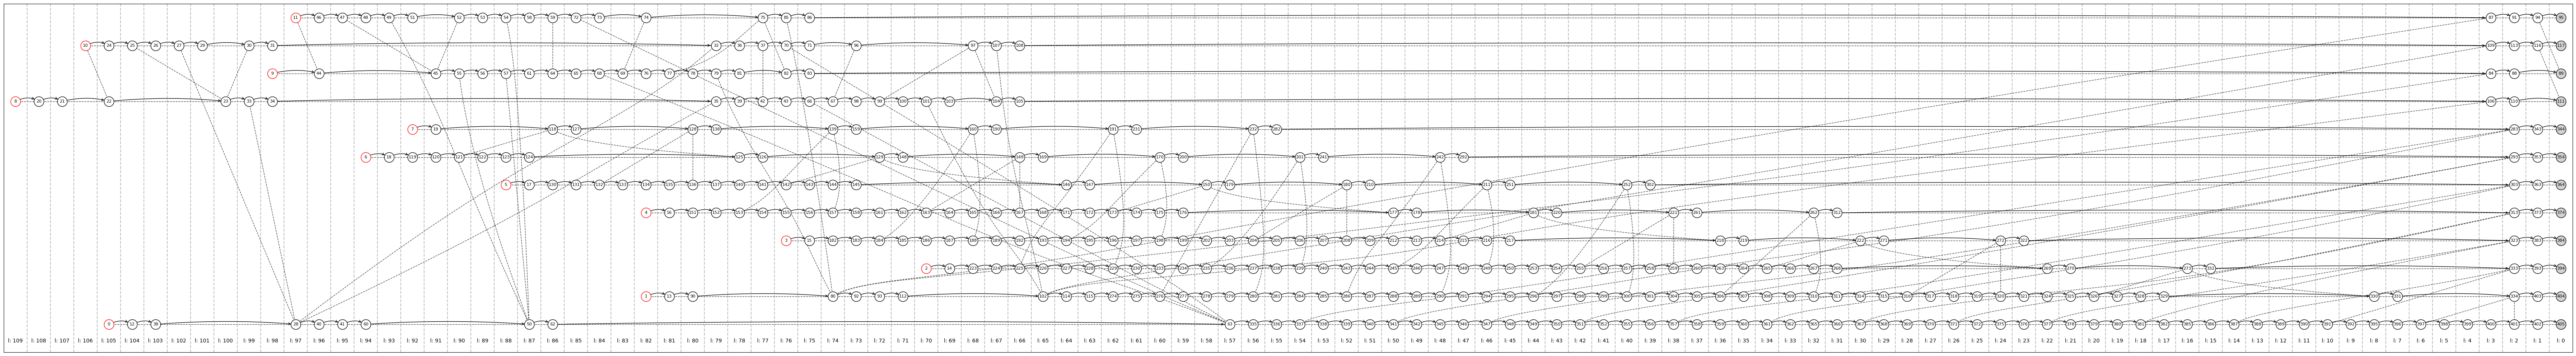

In [6]:
# --- Configuration ---
N = 15
a = 7  # gcd(7, 15) = 1; order r = 4

print(f"=== Shor's Algorithm: N = {N}, a = {a} ===")
print(f"  n_work   = {ceil(log2(N))} qubits")
print(f"  n_count  = {2 * ceil(log2(N))} qubits")
print(f"  total    = {2 * ceil(log2(N)) + ceil(log2(N))} qubits")
print()

# Build the circuit
circuit_15, count_q_15, work_q_15 = shor_circuit(N, a)

# Transpile to MBQC pattern
pattern_15 = circuit_15.transpile().pattern

# Extract the graph state BEFORE any preprocessing
G_full_15 = pattern_to_networkx(pattern_15)

print(f"Resource graph state (before preprocessing):")
print(f"  Nodes: {G_full_15.number_of_nodes()}, Edges: {G_full_15.number_of_edges()}")
print(f"  Connected: {nx.is_connected(G_full_15)}")
print()

# Show the pattern structure
print(pattern_15.to_ascii(left_to_right=True, limit=15))
pattern_15.draw_graph(flow_from_pattern=False)

### Preprocessing: standardize, shift signals, and Pauli measurements

The raw MBQC pattern is typically very large. By standardizing, shifting signals,
and preprocessing Pauli measurements, we can significantly reduce the graph state.
This mirrors exactly what we did in the Deutsch-Jozsa notebook.

In [7]:
# Standardize and shift signals
pattern_15.standardize()
pattern_15.shift_signals()
print("After standardize + shift_signals:")
print(pattern_15.to_ascii(left_to_right=True, limit=15))
print()

After standardize + shift_signals:
N(12) N(13) N(14) N(15) N(16) N(17) N(18) N(19) N(20) N(21) N(22) N(23) N(24) N(25)...(1284 more commands)



After Pauli measurement preprocessing:
N(256) N(262) N(266) N(272) N(273) N(277) N(23) N(26) N(283) N(29) N(287) N(34) N(293) N(297) N(45)...(148 more commands)

Reduced graph state (after preprocessing):
  Nodes: 84, Edges: 88
The pattern is consistent with gflow structure. (not with flow)


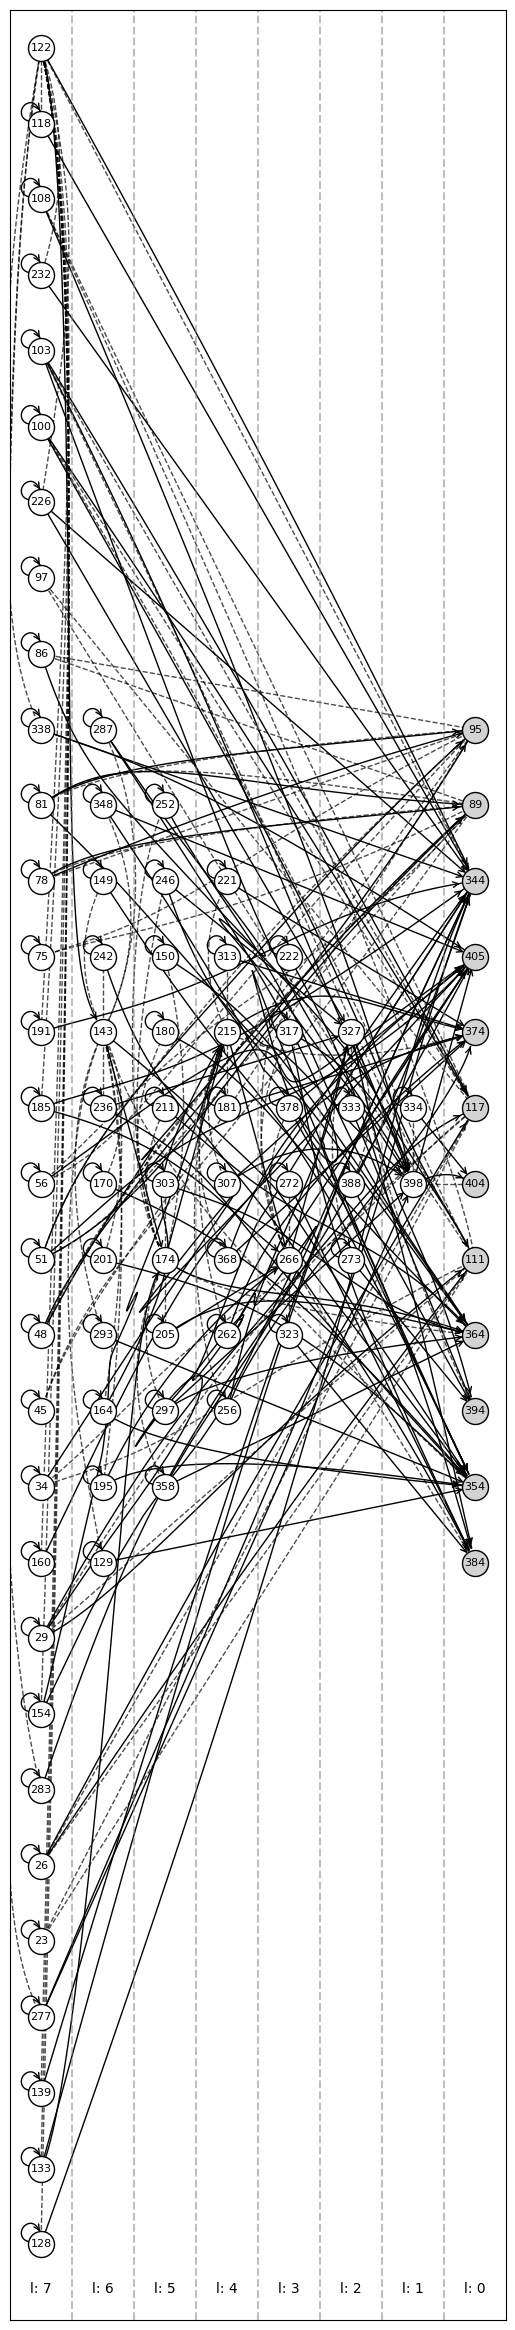

In [8]:
# Preprocess Pauli measurements
pattern_15.perform_pauli_measurements()
pattern_15.standardize()

print("After Pauli measurement preprocessing:")
print(
    pattern_15.to_ascii(
        left_to_right=True,
        limit=16,
        target=[CommandKind.N, CommandKind.M, CommandKind.C],
    )
)

# Extract the reduced graph
G_reduced_15 = pattern_to_networkx(pattern_15)
print(f"\nReduced graph state (after preprocessing):")
print(f"  Nodes: {G_reduced_15.number_of_nodes()}, Edges: {G_reduced_15.number_of_edges()}")

pattern_15.draw_graph(flow_from_pattern=True)

### Visualize the full and reduced graph states side by side

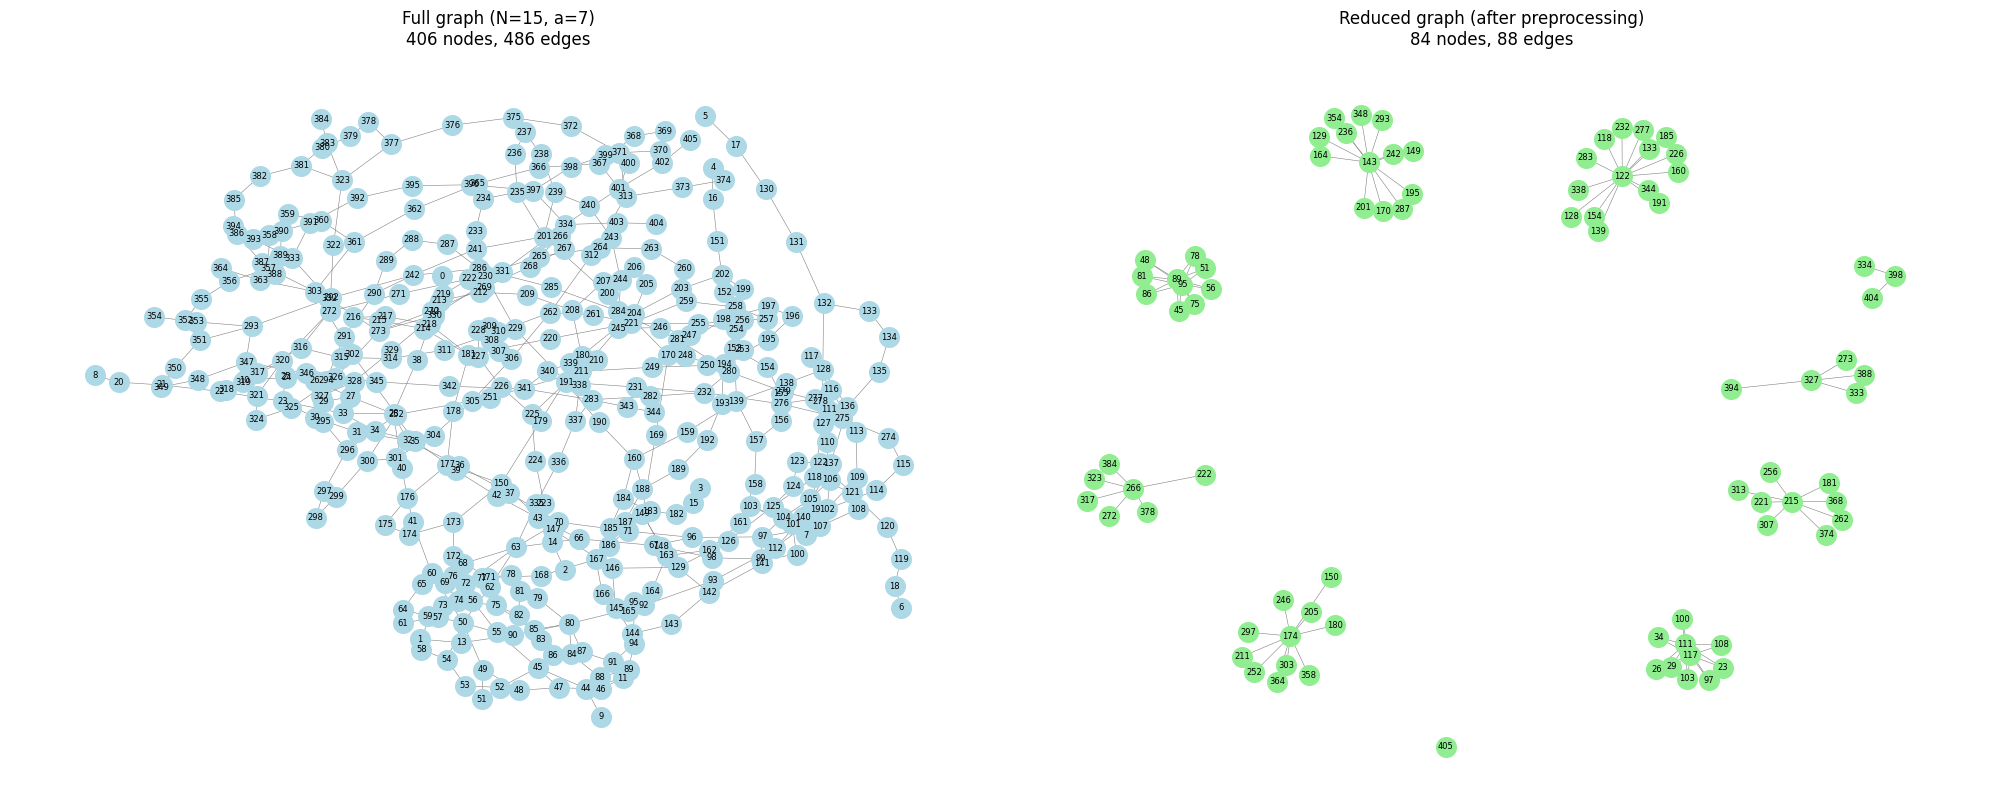

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full graph
ax = axes[0]
pos_full = nx.spring_layout(G_full_15, seed=42, k=1.5 / np.sqrt(max(G_full_15.number_of_nodes(), 1)))
nx.draw(G_full_15, pos_full, ax=ax, with_labels=True, node_color="lightblue",
        node_size=200, font_size=6, edge_color="gray", width=0.4)
ax.set_title(f"Full graph (N=15, a=7)\n{G_full_15.number_of_nodes()} nodes, {G_full_15.number_of_edges()} edges")

# Reduced graph
ax = axes[1]
if G_reduced_15.number_of_nodes() > 0:
    pos_red = nx.spring_layout(G_reduced_15, seed=42, k=1.5 / np.sqrt(max(G_reduced_15.number_of_nodes(), 1)))
    nx.draw(G_reduced_15, pos_red, ax=ax, with_labels=True, node_color="lightgreen",
            node_size=200, font_size=6, edge_color="gray", width=0.4)
    ax.set_title(f"Reduced graph (after preprocessing)\n{G_reduced_15.number_of_nodes()} nodes, {G_reduced_15.number_of_edges()} edges")
else:
    ax.set_title("Reduced graph: all qubits preprocessed!\n(all measurements were Pauli)")
    ax.text(0.5, 0.5, "Empty graph\n(fully classical)", ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.show()

## 7. Comparing different bases $a$ for $N = 15$

Different values of $a$ lead to different oracle circuits and thus different resource graph states.
The valid coprime bases for $N = 15$ are $a \in \{2, 4, 7, 8, 11, 13, 14\}$.
Let us build the circuit for each and compare the graph state sizes.

Valid coprime bases for N=15: [2, 4, 7, 8, 11, 13, 14]

a =  2  (order r = 4)  |  Full:  420 nodes,   504 edges  |  Reduced:   96 nodes,   208 edges  |  Reduction: 77.1%
a =  4  (order r = 2)  |  Full:  354 nodes,   414 edges  |  Reduced:   76 nodes,    72 edges  |  Reduction: 78.5%
a =  7  (order r = 4)  |  Full:  406 nodes,   486 edges  |  Reduced:   84 nodes,    88 edges  |  Reduction: 79.3%
a =  8  (order r = 4)  |  Full:  420 nodes,   504 edges  |  Reduced:   96 nodes,   208 edges  |  Reduction: 77.1%
a = 11  (order r = 2)  |  Full:  384 nodes,   456 edges  |  Reduced:   84 nodes,   128 edges  |  Reduction: 78.1%
a = 13  (order r = 4)  |  Full:  428 nodes,   516 edges  |  Reduced:   96 nodes,   208 edges  |  Reduction: 77.6%
a = 14  (order r = 2)  |  Full:  318 nodes,   366 edges  |  Reduced:   68 nodes,    56 edges  |  Reduction: 78.6%


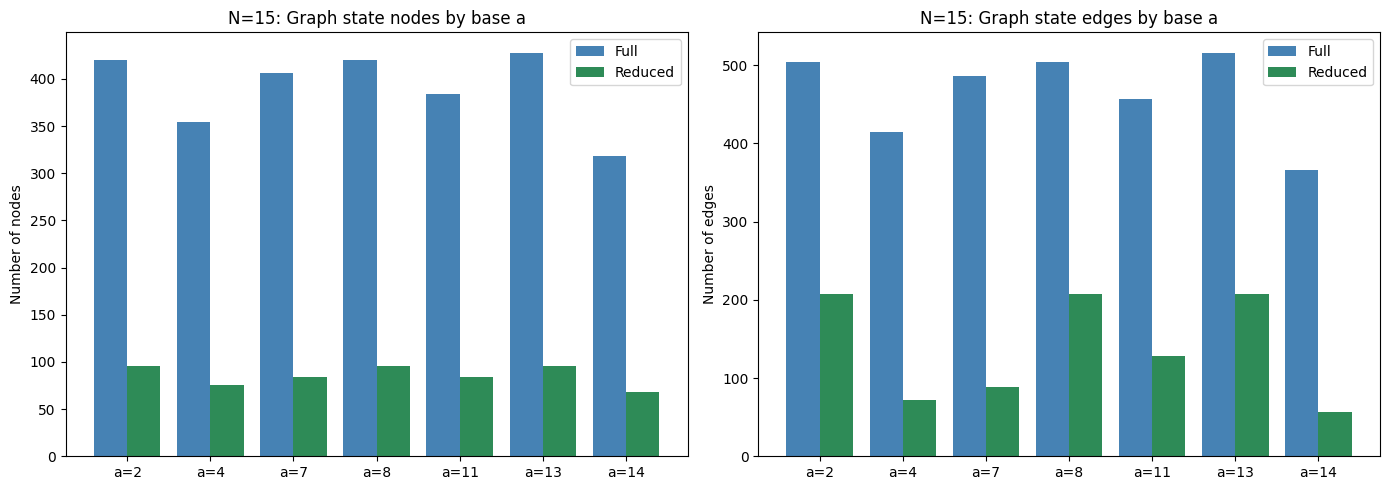

In [10]:
valid_bases_15 = [a for a in range(2, 15) if gcd(a, 15) == 1]
print(f"Valid coprime bases for N=15: {valid_bases_15}\n")

results_15 = []

for a_val in valid_bases_15:
    # Compute the order of a mod 15
    r = 1
    while pow(a_val, r, 15) != 1:
        r += 1

    # Build circuit and transpile
    circ, cq, wq = shor_circuit(15, a_val)
    pat = circ.transpile().pattern
    G_before = pattern_to_networkx(pat)
    n_before, e_before = G_before.number_of_nodes(), G_before.number_of_edges()

    # Preprocess
    pat.standardize()
    pat.shift_signals()
    pat.perform_pauli_measurements()
    pat.standardize()
    G_after = pattern_to_networkx(pat)
    n_after, e_after = G_after.number_of_nodes(), G_after.number_of_edges()

    results_15.append({
        'a': a_val, 'order': r,
        'nodes_full': n_before, 'edges_full': e_before,
        'nodes_reduced': n_after, 'edges_reduced': e_after,
    })

    print(f"a = {a_val:2d}  (order r = {r})  |  "
          f"Full: {n_before:4d} nodes, {e_before:5d} edges  |  "
          f"Reduced: {n_after:4d} nodes, {e_after:5d} edges  |  "
          f"Reduction: {100*(1 - n_after/max(n_before,1)):.1f}%")

# Summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bases = [r['a'] for r in results_15]
x = np.arange(len(bases))

axes[0].bar(x - 0.2, [r['nodes_full'] for r in results_15], 0.4, label='Full', color='steelblue')
axes[0].bar(x + 0.2, [r['nodes_reduced'] for r in results_15], 0.4, label='Reduced', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'a={b}' for b in bases])
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('N=15: Graph state nodes by base a')
axes[0].legend()

axes[1].bar(x - 0.2, [r['edges_full'] for r in results_15], 0.4, label='Full', color='steelblue')
axes[1].bar(x + 0.2, [r['edges_reduced'] for r in results_15], 0.4, label='Reduced', color='seagreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'a={b}' for b in bases])
axes[1].set_ylabel('Number of edges')
axes[1].set_title('N=15: Graph state edges by base a')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
upto = 17
for number in range(3, upto+1):
    numofcoprimes = len([a for a in range(2, number) if gcd(a, number) == 1])
    print(f"N={number}: number of coprimes = {numofcoprimes}")

print(f'total sum of coprimes for N=3..{upto}: 2 *', sum(len([a for a in range(2, number) if gcd(a, number) == 1]) for number in range(3, upto+1)))


N=3: number of coprimes = 1
N=4: number of coprimes = 1
N=5: number of coprimes = 3
N=6: number of coprimes = 1
N=7: number of coprimes = 5
N=8: number of coprimes = 3
N=9: number of coprimes = 5
N=10: number of coprimes = 3
N=11: number of coprimes = 9
N=12: number of coprimes = 3
N=13: number of coprimes = 11
N=14: number of coprimes = 5
N=15: number of coprimes = 7
N=16: number of coprimes = 7
N=17: number of coprimes = 15
total sum of coprimes for N=3..17: 2 * 79


## 8. Dataset: Graph states for all (N, a) combinations, N = 3 to 17

For each $N$ from 3 to 17 and every base $a \in \{2, \ldots, N-1\}$ coprime to $N$,
we build the Shor circuit, transpile it to an MBQC pattern, and extract the
**full (non-reduced) resource graph state**.

We collect all graphs and their statistics for analysis and plotting.

In [31]:
import time
import signal

# ============================================================
# Build dataset of all (N, a) graph states for N = 3..17
# ============================================================

TIMEOUT_SECONDS = 10  # skip any (N, a) pair that takes longer than this

class GraphTimeout(Exception):
    pass

def _timeout_handler(signum, frame):
    raise GraphTimeout("Timed out")

max_N = 17

all_results = []
all_graphs = {}
ok_count = 0
skip_count = 0
err_count = 0

for N_val in range(3, max_N + 1):
    valid_bases = [a for a in range(2, N_val) if gcd(a, N_val) == 1]

    for a_val in valid_bases:
        # multiplicative order of a mod N
        r = 1
        while pow(a_val, r, N_val) != 1:
            r += 1

        t0 = time.time()
        old_handler = signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(TIMEOUT_SECONDS)

        try:
            circ, cq, wq = shor_circuit(N_val, a_val)
            pat = circ.transpile().pattern
            G_full = pattern_to_networkx(pat)

            # Reduce
            pat.standardize()
            pat.shift_signals()
            pat.perform_pauli_measurements()
            pat.standardize()
            G_reduced = pattern_to_networkx(pat)

            signal.alarm(0)
            elapsed = time.time() - t0

            res = {
                "N": N_val, "a": a_val, "order": r,
                "nodes_full": G_full.number_of_nodes(),
                "edges_full": G_full.number_of_edges(),
                "nodes_reduced": G_reduced.number_of_nodes(),
                "edges_reduced": G_reduced.number_of_edges(),
                "time": elapsed, "status": "ok",
            }
            all_results.append(res)
            all_graphs[(N_val, a_val)] = {"full": G_full, "reduced": G_reduced}
            ok_count += 1

            red_pct = int(100 * (1 - G_reduced.number_of_nodes() / G_full.number_of_nodes()))
            print(f"N={N_val:>2}, a={a_val:>2}  r={r:<2}  "
                  f"Full: {G_full.number_of_nodes():>5} nodes, {G_full.number_of_edges():>6} edges  |  "
                  f"Reduced: {G_reduced.number_of_nodes():>5} nodes, {G_reduced.number_of_edges():>6} edges  "
                  f"({red_pct}% reduction)   [{elapsed:.1f}s]")

        except GraphTimeout:
            signal.alarm(0)
            elapsed = time.time() - t0
            all_results.append({
                "N": N_val, "a": a_val, "order": r,
                "status": "timeout", "time": elapsed,
            })
            skip_count += 1
            print(f"N={N_val:>2}, a={a_val:>2}  r={r:<2}  SKIPPED (>{TIMEOUT_SECONDS}s)  [{elapsed:.1f}s]")

        except Exception as e:
            signal.alarm(0)
            elapsed = time.time() - t0
            all_results.append({
                "N": N_val, "a": a_val, "order": r,
                "status": f"error: {e}", "time": elapsed,
            })
            err_count += 1
            print(f"N={N_val:>2}, a={a_val:>2}  r={r:<2}  ERROR: {e}   [{elapsed:.1f}s]")

        finally:
            signal.signal(signal.SIGALRM, old_handler)

print(f"\n{'='*60}")
print(f"Done!  OK: {ok_count} | Timeout: {skip_count} | Error: {err_count} | Total: {len(all_results)}")
print(f"{'='*60}")

N= 3, a= 2 (r= 2) | Full:   135 nodes,    158 edges | Reduced:    35 nodes,     56 edges | 0.0s
N= 4, a= 3 (r= 2) | Full:    95 nodes,    106 edges | Reduced:    23 nodes,     16 edges | 0.0s
N= 5, a= 2 (r= 4) | Full:   825 nodes,   1042 edges | Reduced:   247 nodes,   3038 edges | 0.5s
N= 5, a= 3 (r= 4) | Full:   825 nodes,   1042 edges | Reduced:   247 nodes,   3054 edges | 0.5s
N= 5, a= 4 (r= 2) | Full:   411 nodes,    502 edges | Reduced:   114 nodes,    414 edges | 0.1s
N= 6, a= 5 (r= 2) | Full:   411 nodes,    502 edges | Reduced:   113 nodes,    398 edges | 0.1s
N= 7, a= 2 (r= 3) | SKIPPED (>5s) | 5.0s
N= 7, a= 3 (r= 6) | SKIPPED (>5s) | 5.0s
N= 7, a= 4 (r= 3) | SKIPPED (>5s) | 5.0s
N= 7, a= 5 (r= 6) | SKIPPED (>5s) | 5.0s
N= 7, a= 6 (r= 2) | Full:   585 nodes,    730 edges | Reduced:   164 nodes,    990 edges | 0.2s
N= 8, a= 3 (r= 2) | Full:   345 nodes,    418 edges | Reduced:    95 nodes,    254 edges | 0.0s
N= 8, a= 5 (r= 2) | Full:   287 nodes,    342 edges | Reduced:    75

### Summary table

In [32]:
# Print a formatted summary table
print(f"{'N':>3} {'a':>3} {'r':>3} {'Nodes(F)':>9} {'Edges(F)':>9} {'Nodes(R)':>9} {'Edges(R)':>9} {'Red%':>6} {'Status':>8}")
print("-" * 70)
for res in all_results:
    red_pct = 100 * (1 - res['nodes_reduced'] / max(res['nodes_full'], 1)) if res['status'] == 'ok' else 0
    print(f"{res['N']:3d} {res['a']:3d} {res['order']:3d} "
          f"{res['nodes_full']:9d} {res['edges_full']:9d} "
          f"{res['nodes_reduced']:9d} {res['edges_reduced']:9d} "
          f"{red_pct:5.1f}% {res['status']:>8}")

ok_results = [r for r in all_results if r['status'] == 'ok']
print(f"\nSuccessful: {len(ok_results)} / {len(all_results)}")
print(f"Total full nodes across all graphs: {sum(r['nodes_full'] for r in ok_results)}")
print(f"Total full edges across all graphs: {sum(r['edges_full'] for r in ok_results)}")

  N   a   r  Nodes(F)  Edges(F)  Nodes(R)  Edges(R)   Red%   Status
----------------------------------------------------------------------
  3   2   2       135       158        35        56  74.1%       ok
  4   3   2        95       106        23        16  75.8%       ok
  5   2   4       825      1042       247      3038  70.1%       ok
  5   3   4       825      1042       247      3054  70.1%       ok
  5   4   2       411       502       114       414  72.3%       ok
  6   5   2       411       502       113       398  72.5%       ok
  7   2   3         0         0         0         0   0.0%  timeout
  7   3   6         0         0         0         0   0.0%  timeout
  7   4   3         0         0         0         0   0.0%  timeout
  7   5   6         0         0         0         0   0.0%  timeout
  7   6   2       585       730       164       990  72.0%       ok
  8   3   2       345       418        95       254  72.5%       ok
  8   5   2       287       342        75    

### Graph visualizations per N

For each $N$, we plot all (full, reduced) graph-state pairs side by side for every valid base $a$.

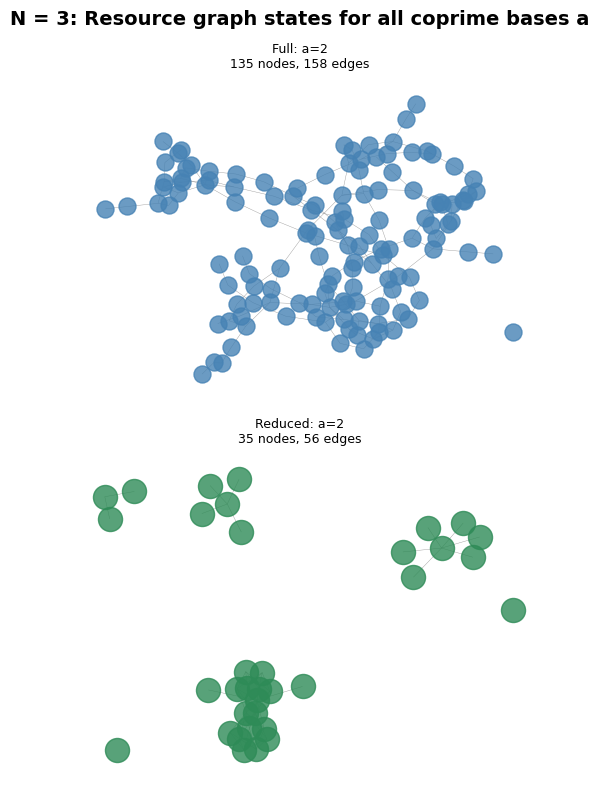

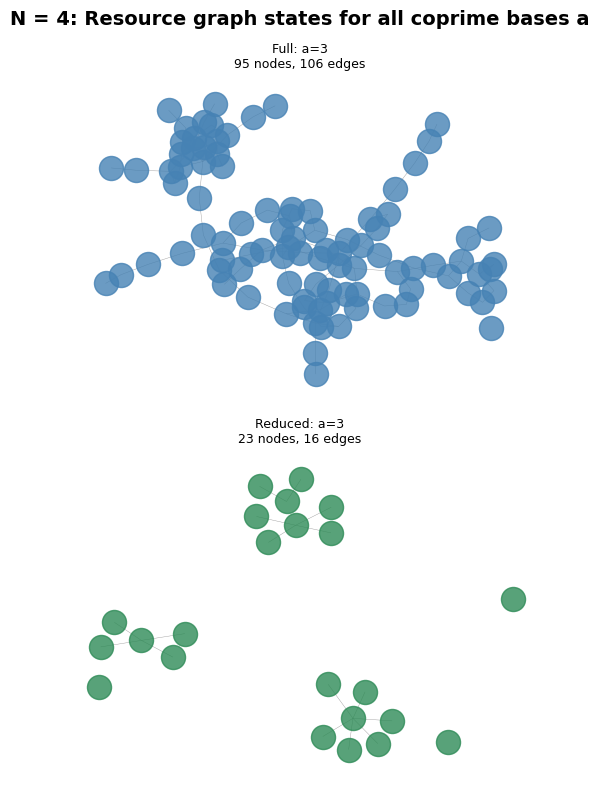

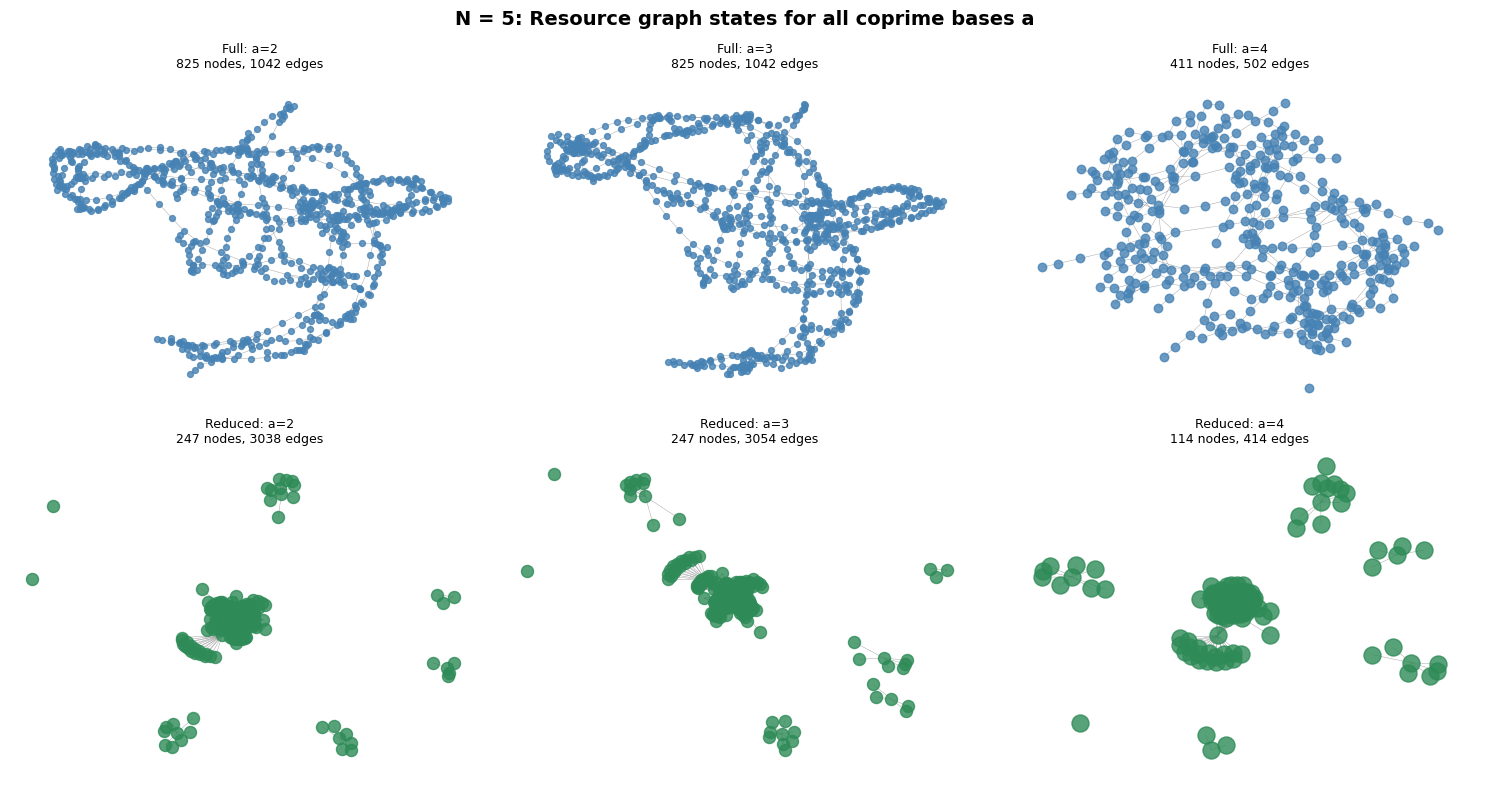

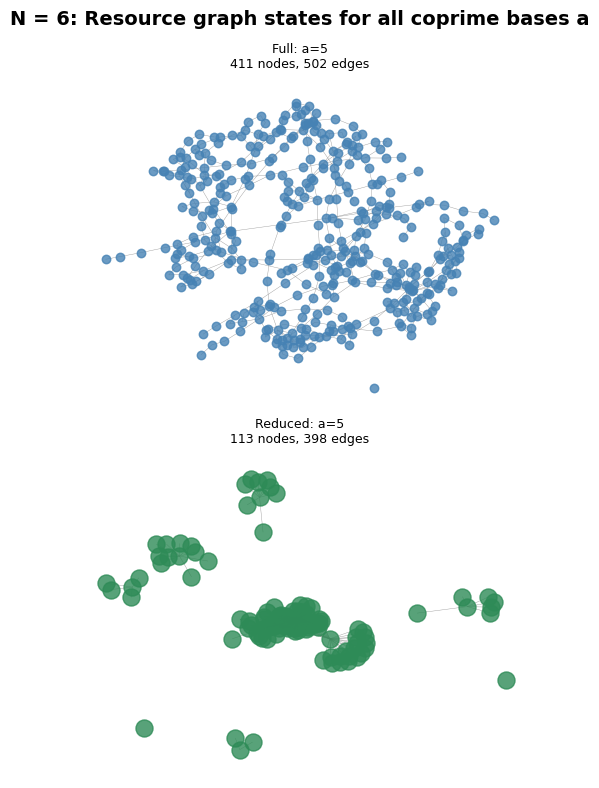

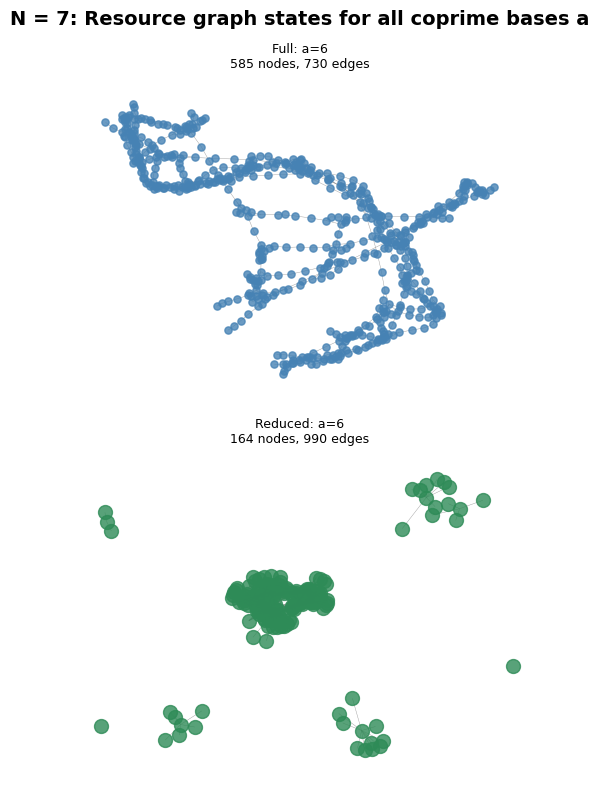

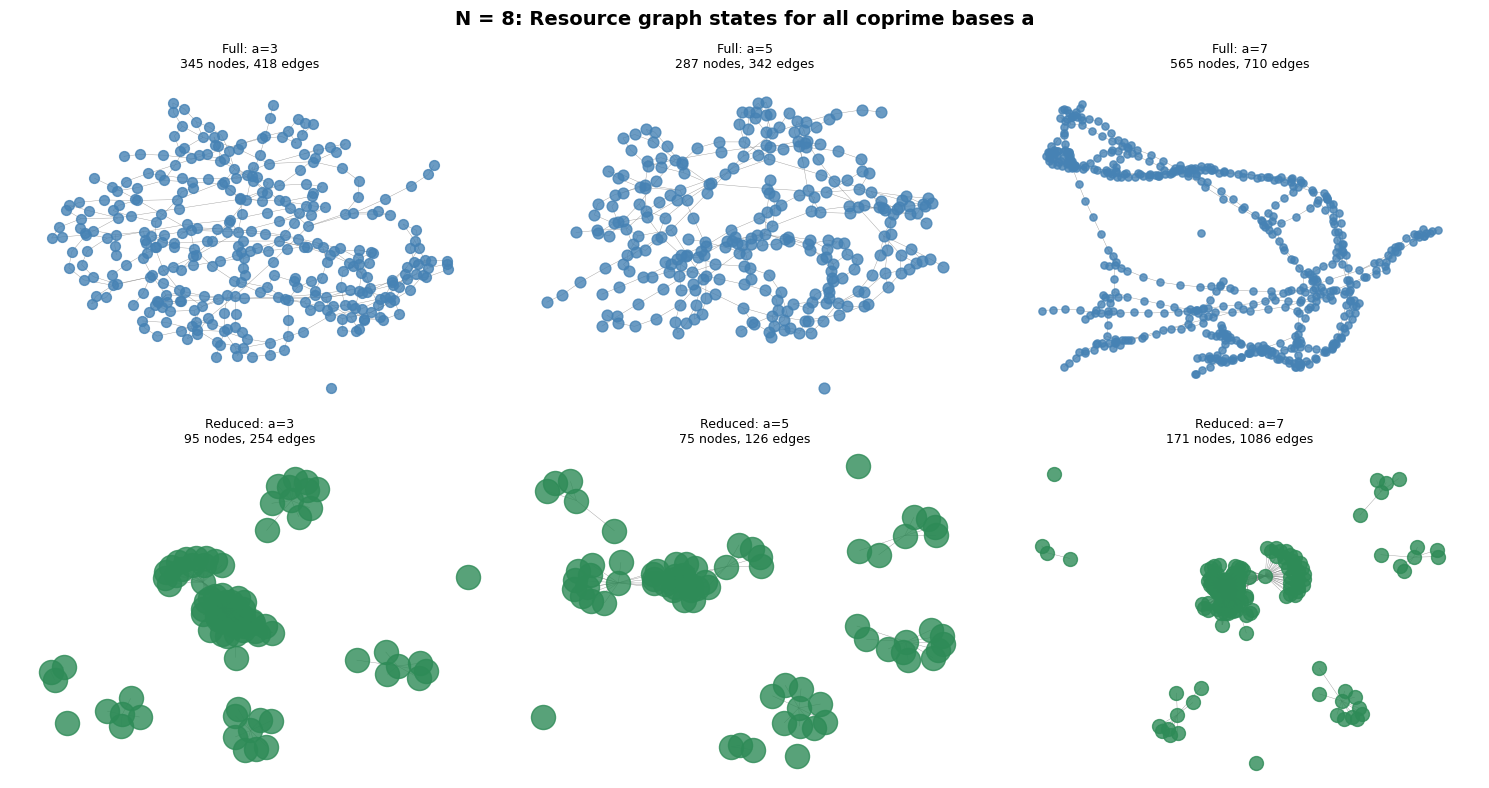

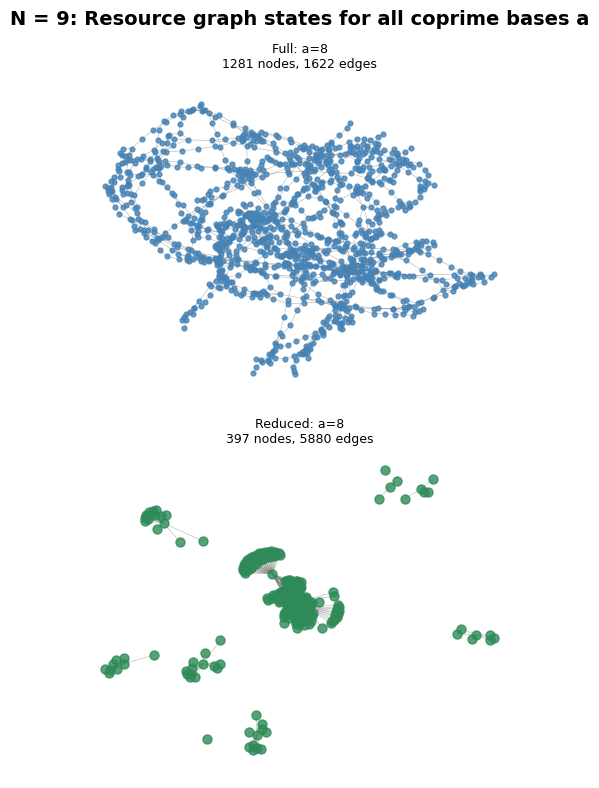

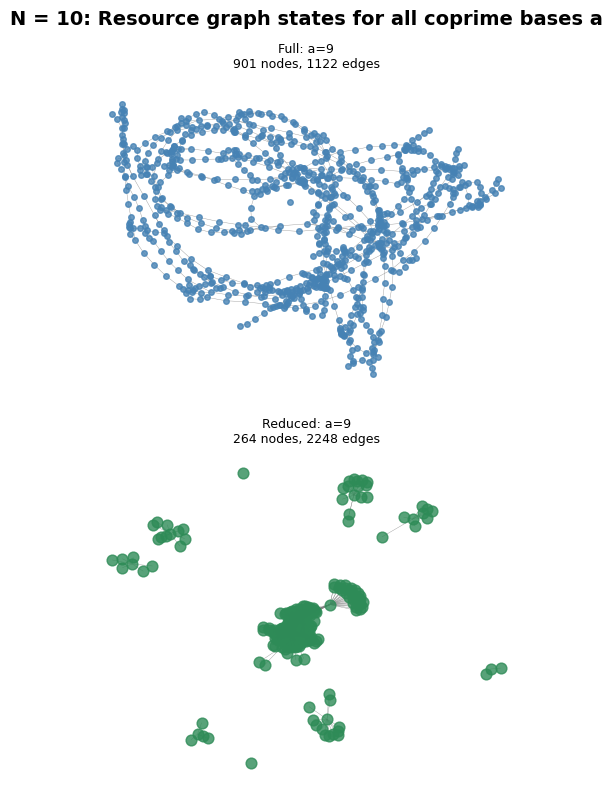

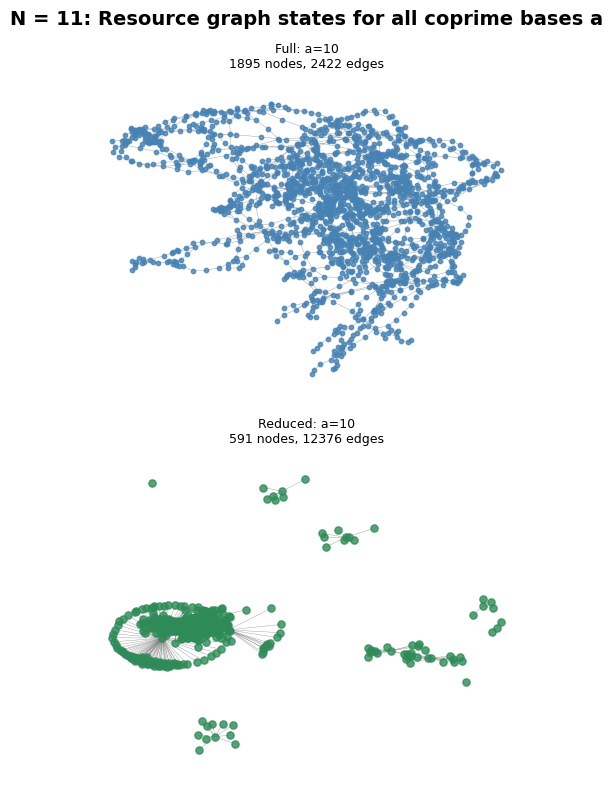

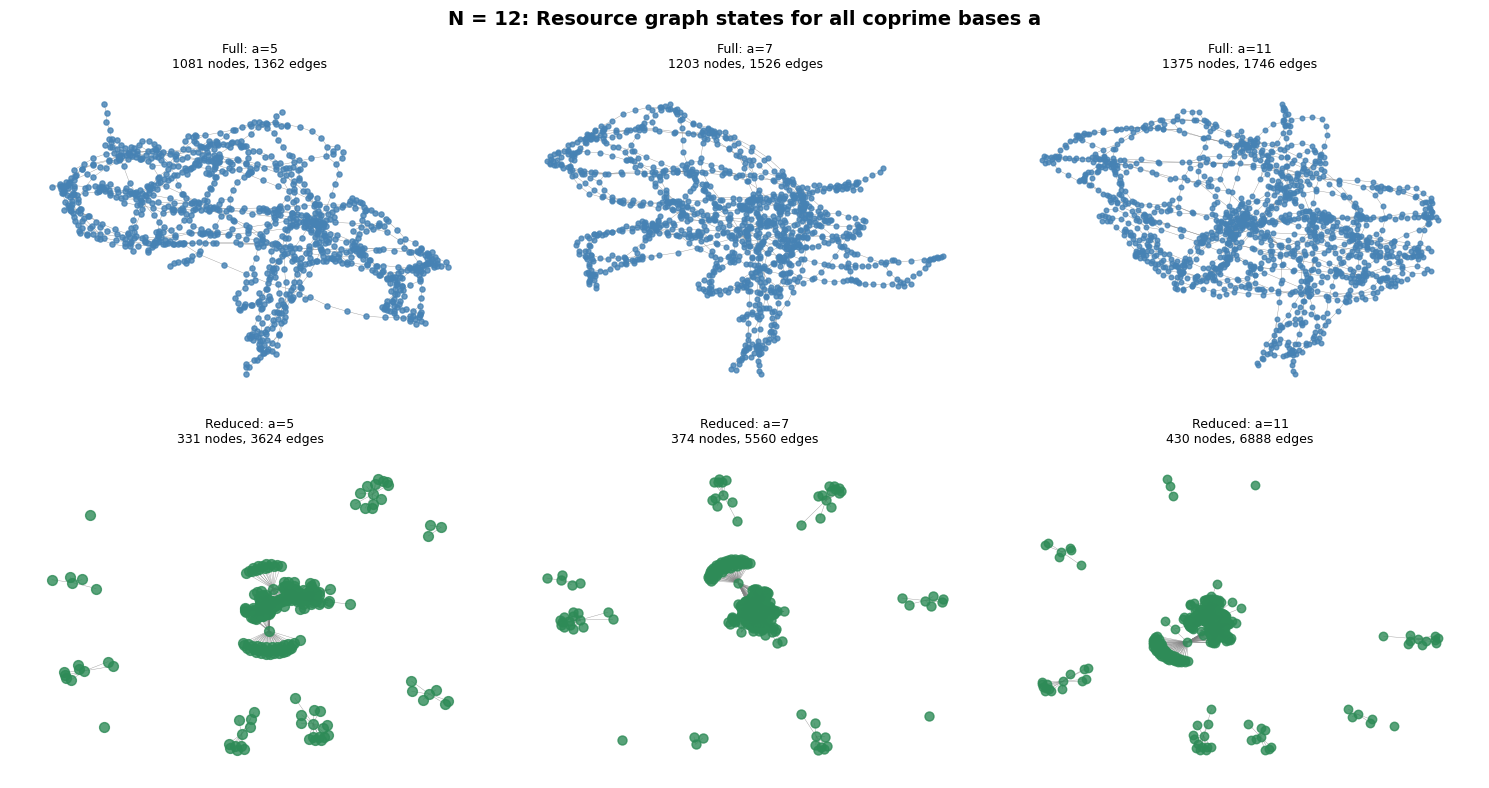

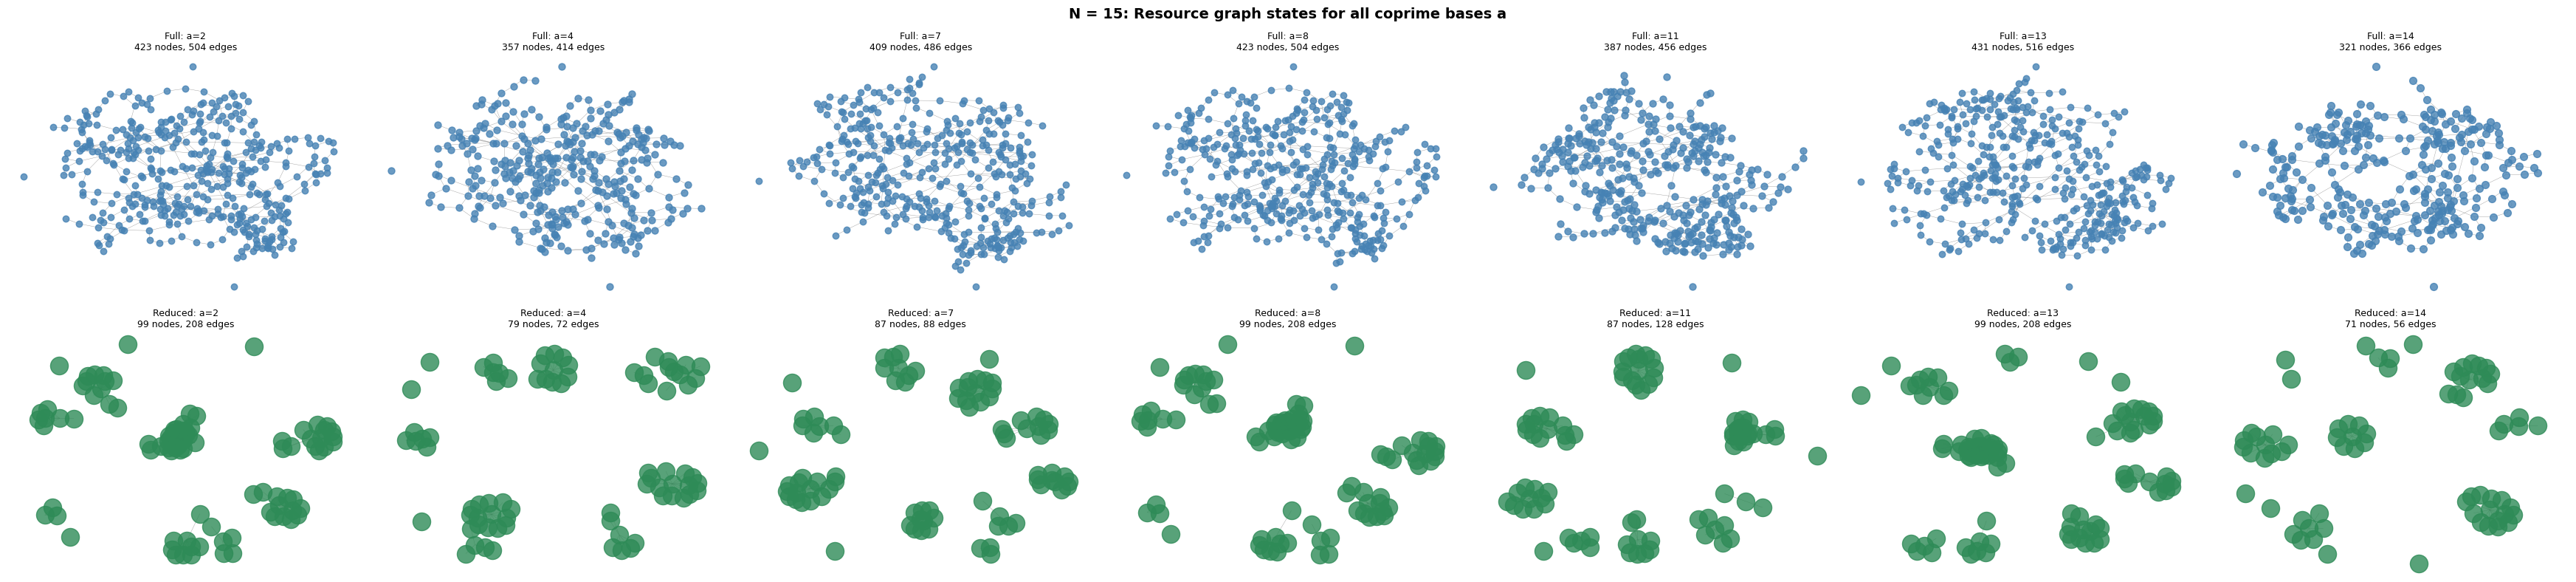

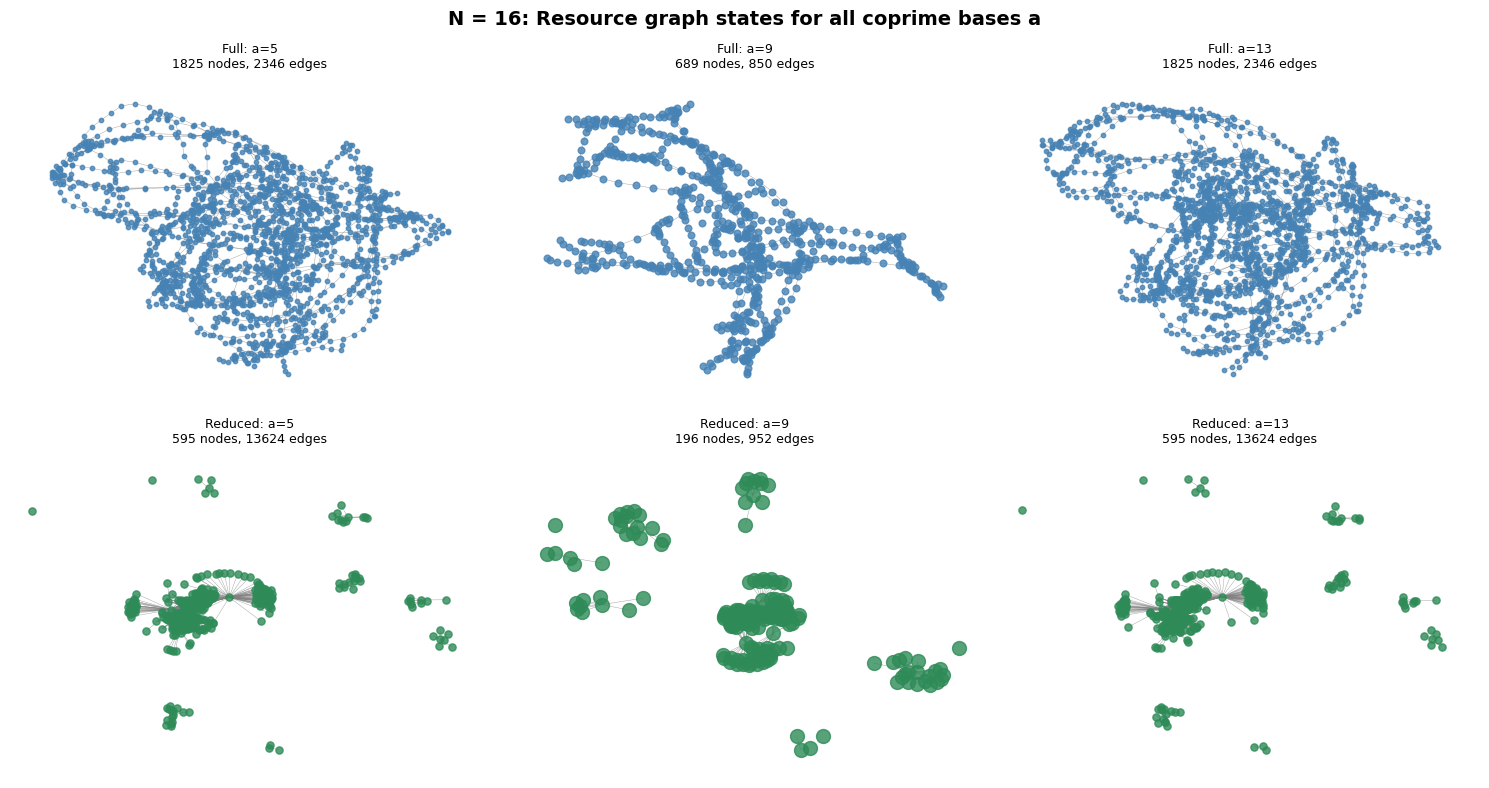

In [34]:
# Plot all graph states grouped by N
# For each N, show full and reduced graphs side by side for every base a

ok_results = [r for r in all_results if r['status'] == 'ok']
N_values = sorted(set(r['N'] for r in ok_results))

for N_val in N_values:
    N_results = [r for r in ok_results if r['N'] == N_val]
    n_bases = len(N_results)
    
    if n_bases == 0:
        continue
    
    # Two rows per N: top row = full graphs, bottom row = reduced graphs
    fig, axes = plt.subplots(2, n_bases, figsize=(5 * n_bases, 8))
    if n_bases == 1:
        axes = axes.reshape(2, 1)
    
    fig.suptitle(f'N = {N_val}: Resource graph states for all coprime bases a', 
                 fontsize=14, fontweight='bold')
    
    for idx, res in enumerate(N_results):
        a_val = res['a']
        key = (N_val, a_val)
        
        if key not in all_graphs:
            continue
        
        G_full = all_graphs[key]['full']
        G_red = all_graphs[key]['reduced']
        
        # Full graph (top row)
        ax = axes[0, idx]
        if G_full.number_of_nodes() > 0:
            pos = nx.spring_layout(G_full, seed=42, k=1.5 / np.sqrt(max(G_full.number_of_nodes(), 1)))
            nx.draw(G_full, pos, ax=ax, with_labels=False, node_color="steelblue",
                    node_size=max(10, 300 // max(G_full.number_of_nodes() // 50, 1)),
                    edge_color="gray", width=0.3, alpha=0.8)
        ax.set_title(f'Full: a={a_val}\n{G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges',
                     fontsize=9)
        
        # Reduced graph (bottom row)
        ax = axes[1, idx]
        if G_red.number_of_nodes() > 0:
            pos = nx.spring_layout(G_red, seed=42, k=1.5 / np.sqrt(max(G_red.number_of_nodes(), 1)))
            nx.draw(G_red, pos, ax=ax, with_labels=False, node_color="seagreen",
                    node_size=max(10, 300 // max(G_red.number_of_nodes() // 50, 1)),
                    edge_color="gray", width=0.3, alpha=0.8)
            ax.set_title(f'Reduced: a={a_val}\n{G_red.number_of_nodes()} nodes, {G_red.number_of_edges()} edges',
                         fontsize=9)
        else:
            ax.set_title(f'Reduced: a={a_val}\nEmpty (all Pauli)', fontsize=9)
            ax.text(0.5, 0.5, "Empty", ha="center", va="center", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    print()

### Histogram: Full vs Reduced graph sizes across all (N, a) combinations

Bar charts comparing the number of nodes and edges for all generated graph states,
grouped by $N$ with bars for each base $a$.

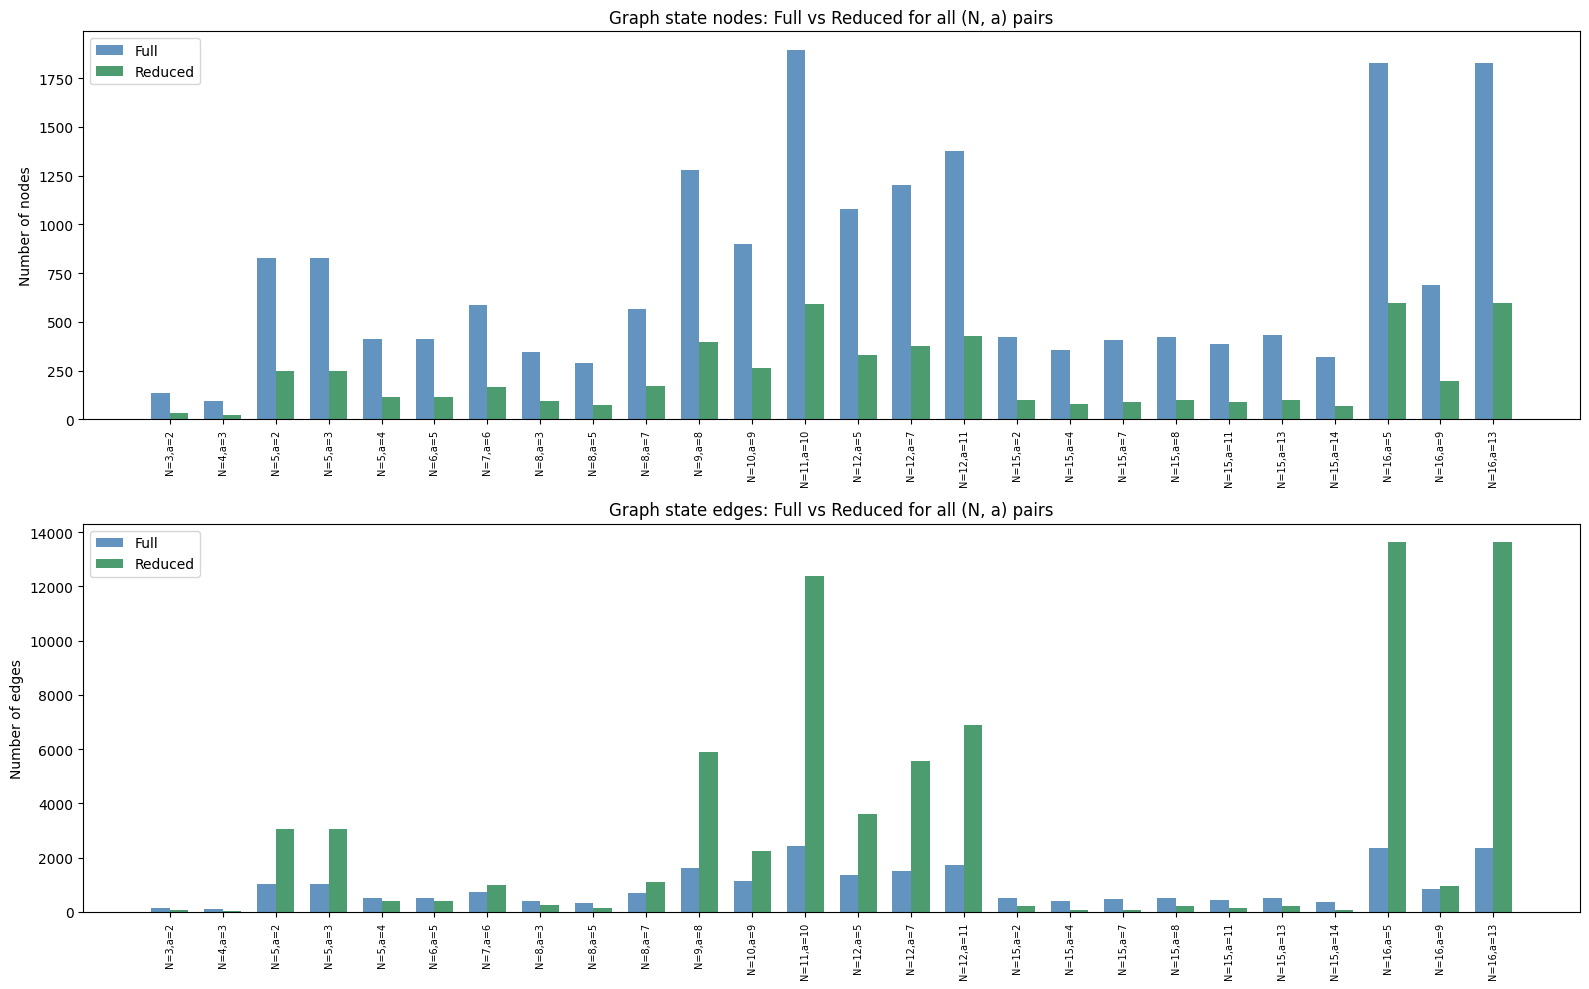

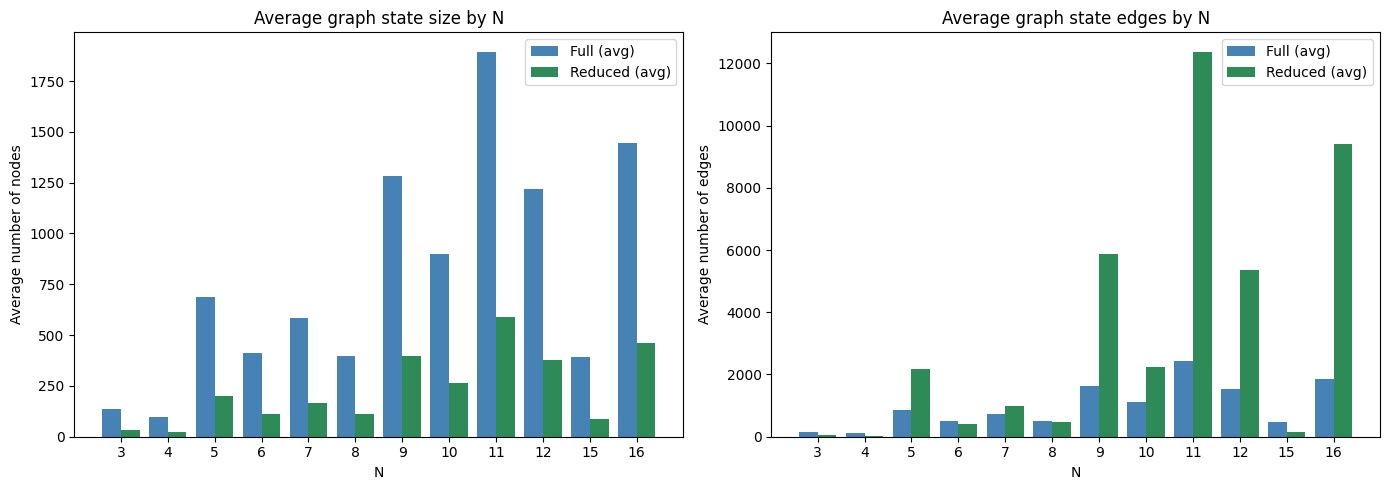

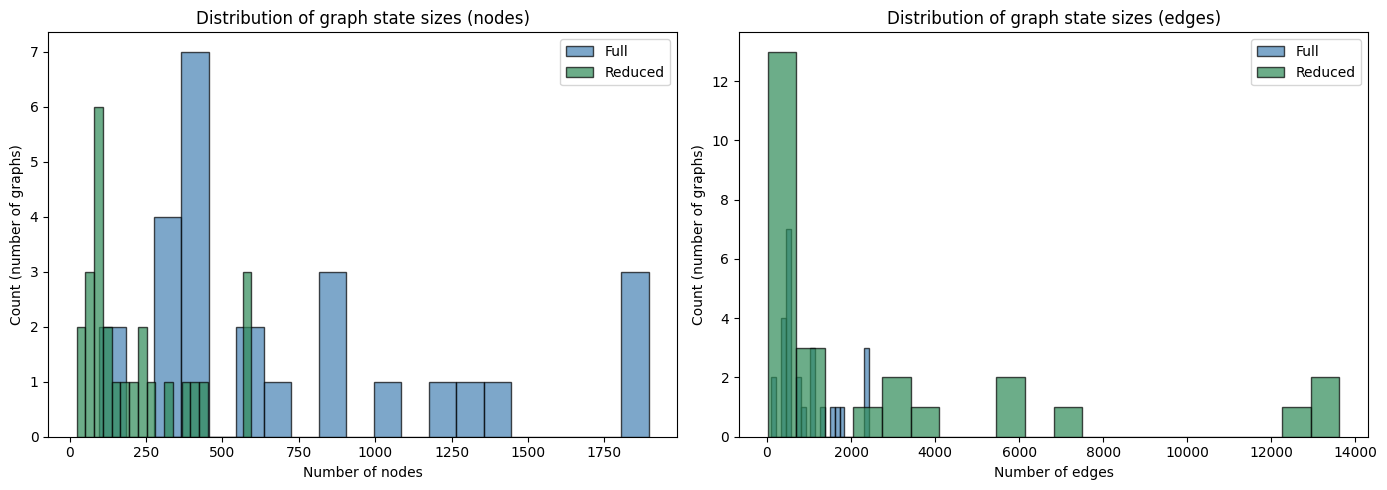

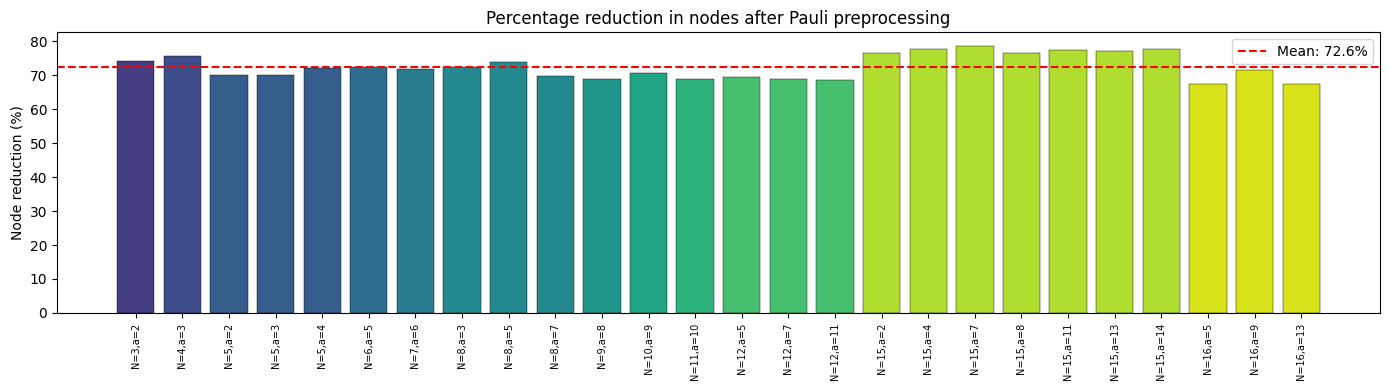

In [35]:
ok_results = [r for r in all_results if r['status'] == 'ok']

# --- Plot 1: Grouped bar chart — nodes and edges, full vs reduced, per (N, a) ---
labels = [f"N={r['N']},a={r['a']}" for r in ok_results]
x_pos = np.arange(len(labels))
bar_w = 0.35

fig, axes = plt.subplots(2, 1, figsize=(max(16, len(labels) * 0.6), 10))

# Nodes
axes[0].bar(x_pos - bar_w/2, [r['nodes_full'] for r in ok_results], bar_w, 
            label='Full', color='steelblue', alpha=0.85)
axes[0].bar(x_pos + bar_w/2, [r['nodes_reduced'] for r in ok_results], bar_w, 
            label='Reduced', color='seagreen', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, rotation=90, fontsize=7)
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('Graph state nodes: Full vs Reduced for all (N, a) pairs')
axes[0].legend()

# Edges
axes[1].bar(x_pos - bar_w/2, [r['edges_full'] for r in ok_results], bar_w, 
            label='Full', color='steelblue', alpha=0.85)
axes[1].bar(x_pos + bar_w/2, [r['edges_reduced'] for r in ok_results], bar_w, 
            label='Reduced', color='seagreen', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[1].set_ylabel('Number of edges')
axes[1].set_title('Graph state edges: Full vs Reduced for all (N, a) pairs')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Plot 2: Per-N summary — average/max/min nodes across bases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

N_values = sorted(set(r['N'] for r in ok_results))
x_N = np.arange(len(N_values))

# Compute per-N statistics
avg_nodes_full = [np.mean([r['nodes_full'] for r in ok_results if r['N'] == N]) for N in N_values]
avg_nodes_red = [np.mean([r['nodes_reduced'] for r in ok_results if r['N'] == N]) for N in N_values]
avg_edges_full = [np.mean([r['edges_full'] for r in ok_results if r['N'] == N]) for N in N_values]
avg_edges_red = [np.mean([r['edges_reduced'] for r in ok_results if r['N'] == N]) for N in N_values]

axes[0].bar(x_N - 0.2, avg_nodes_full, 0.4, label='Full (avg)', color='steelblue')
axes[0].bar(x_N + 0.2, avg_nodes_red, 0.4, label='Reduced (avg)', color='seagreen')
axes[0].set_xticks(x_N)
axes[0].set_xticklabels([str(N) for N in N_values])
axes[0].set_xlabel('N')
axes[0].set_ylabel('Average number of nodes')
axes[0].set_title('Average graph state size by N')
axes[0].legend()

axes[1].bar(x_N - 0.2, avg_edges_full, 0.4, label='Full (avg)', color='steelblue')
axes[1].bar(x_N + 0.2, avg_edges_red, 0.4, label='Reduced (avg)', color='seagreen')
axes[1].set_xticks(x_N)
axes[1].set_xticklabels([str(N) for N in N_values])
axes[1].set_xlabel('N')
axes[1].set_ylabel('Average number of edges')
axes[1].set_title('Average graph state edges by N')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Plot 3: Histogram of node counts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([r['nodes_full'] for r in ok_results], bins=20, color='steelblue', 
             alpha=0.7, label='Full', edgecolor='black')
axes[0].hist([r['nodes_reduced'] for r in ok_results], bins=20, color='seagreen', 
             alpha=0.7, label='Reduced', edgecolor='black')
axes[0].set_xlabel('Number of nodes')
axes[0].set_ylabel('Count (number of graphs)')
axes[0].set_title('Distribution of graph state sizes (nodes)')
axes[0].legend()

axes[1].hist([r['edges_full'] for r in ok_results], bins=20, color='steelblue', 
             alpha=0.7, label='Full', edgecolor='black')
axes[1].hist([r['edges_reduced'] for r in ok_results], bins=20, color='seagreen', 
             alpha=0.7, label='Reduced', edgecolor='black')
axes[1].set_xlabel('Number of edges')
axes[1].set_ylabel('Count (number of graphs)')
axes[1].set_title('Distribution of graph state sizes (edges)')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Plot 4: Reduction percentage ---
reductions = [100 * (1 - r['nodes_reduced'] / max(r['nodes_full'], 1)) for r in ok_results]
fig, ax = plt.subplots(figsize=(max(14, len(labels) * 0.5), 4))
colors = plt.cm.viridis(np.array([r['N'] for r in ok_results]) / max_N)
ax.bar(x_pos, reductions, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('Node reduction (%)')
ax.set_title('Percentage reduction in nodes after Pauli preprocessing')
ax.axhline(y=np.mean(reductions), color='red', linestyle='--', label=f'Mean: {np.mean(reductions):.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Quick status check
ok_count = sum(1 for r in all_results if r['status'] == 'ok')
skip_count = sum(1 for r in all_results if r['status'] == 'timeout')
err_count = len(all_results) - ok_count - skip_count
print(f"Total: {len(all_results)} | OK: {ok_count} | Timeout: {skip_count} | Error: {err_count}")
print("Timed out:", [(r['N'], r['a']) for r in all_results if r['status'] == 'timeout'])
print("Errors:", [(r['N'], r['a'], r['status']) for r in all_results if r['status'] not in ('ok', 'timeout')])

Total: 79 | OK: 26 | Timeout: 53 | Error: 0
Timed out: [(7, 2), (7, 3), (7, 4), (7, 5), (9, 2), (9, 4), (9, 5), (9, 7), (10, 3), (10, 7), (11, 2), (11, 3), (11, 4), (11, 5), (11, 6), (11, 7), (11, 8), (11, 9), (13, 2), (13, 3), (13, 4), (13, 5), (13, 6), (13, 7), (13, 8), (13, 9), (13, 10), (13, 11), (13, 12), (14, 3), (14, 5), (14, 9), (14, 11), (14, 13), (16, 3), (16, 7), (16, 11), (16, 15), (17, 2), (17, 3), (17, 4), (17, 5), (17, 6), (17, 7), (17, 8), (17, 9), (17, 10), (17, 11), (17, 12), (17, 13), (17, 14), (17, 15), (17, 16)]
Errors: []


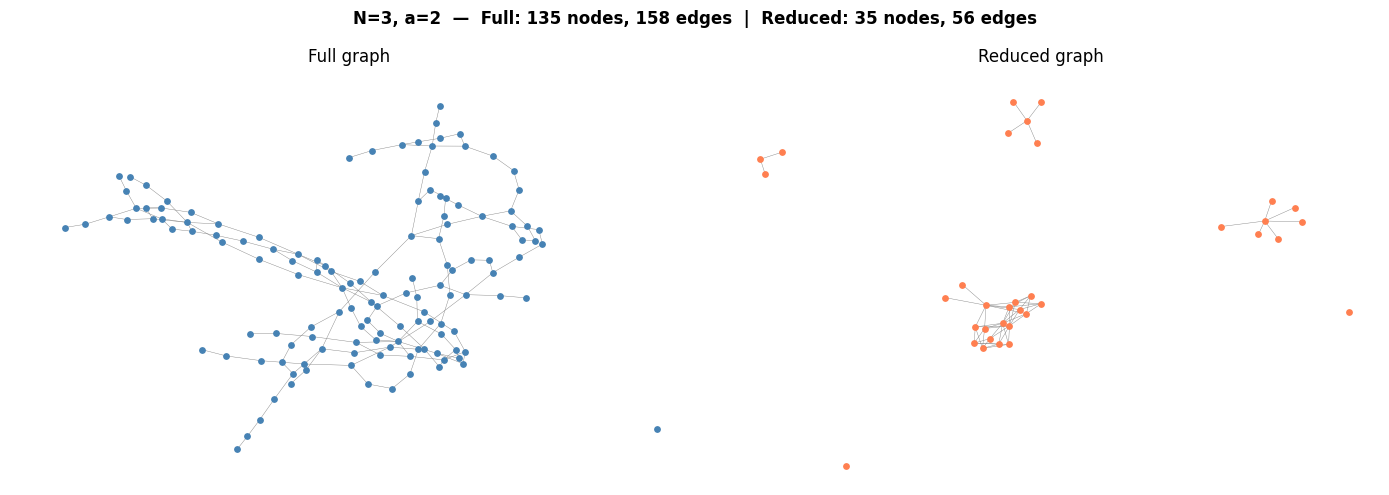

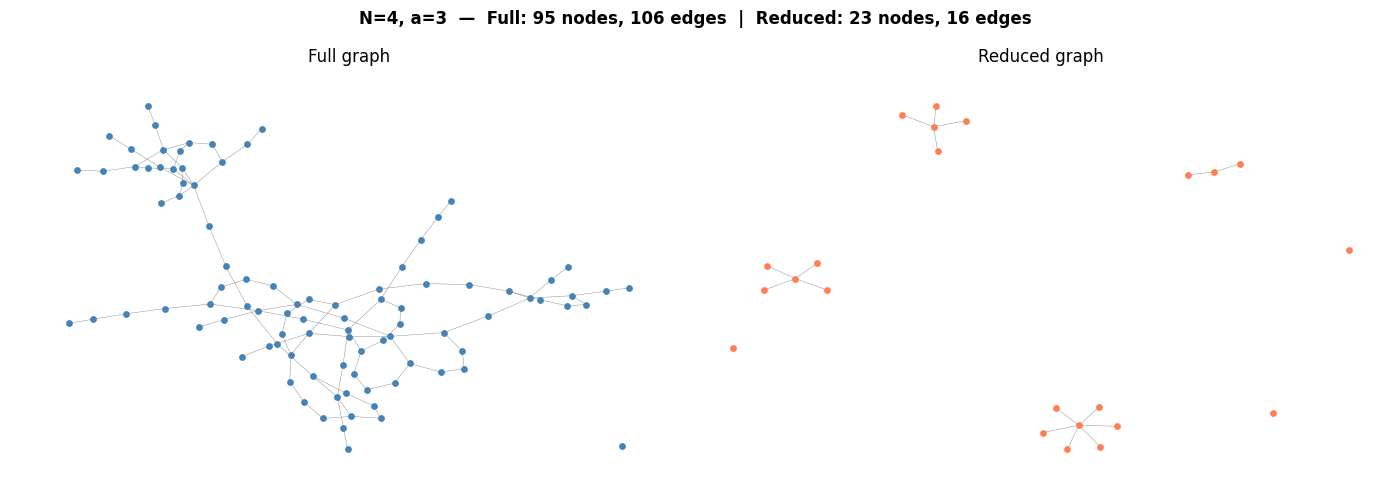

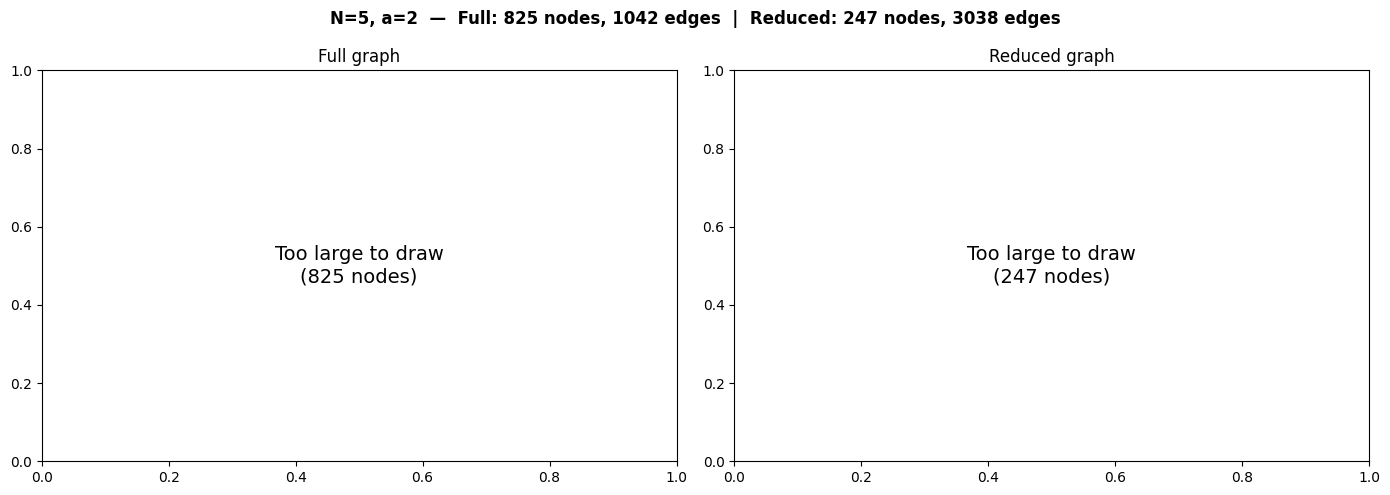

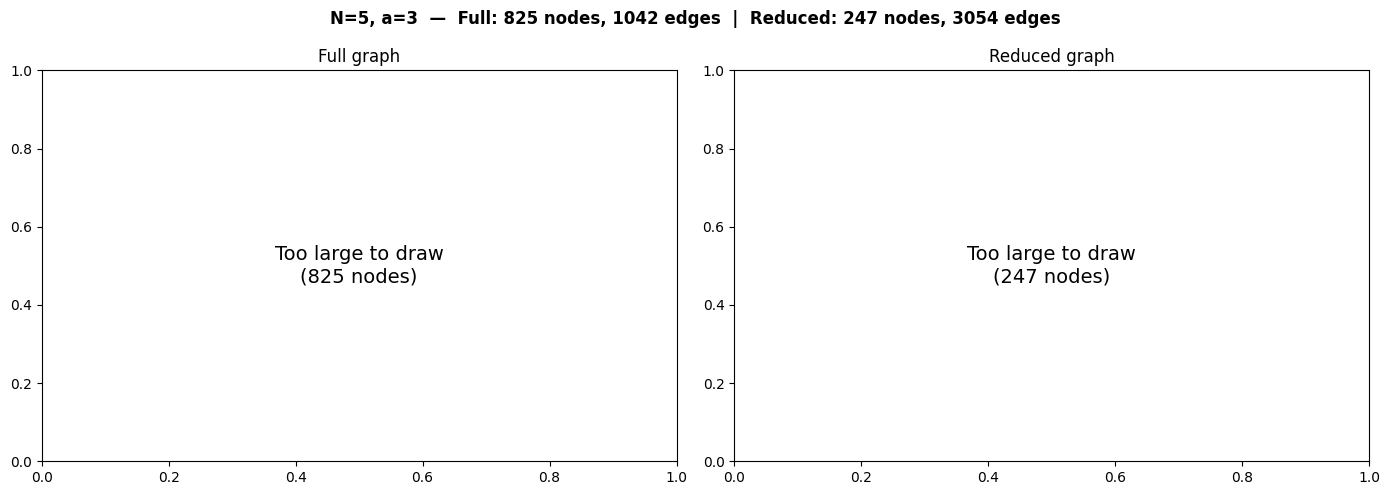

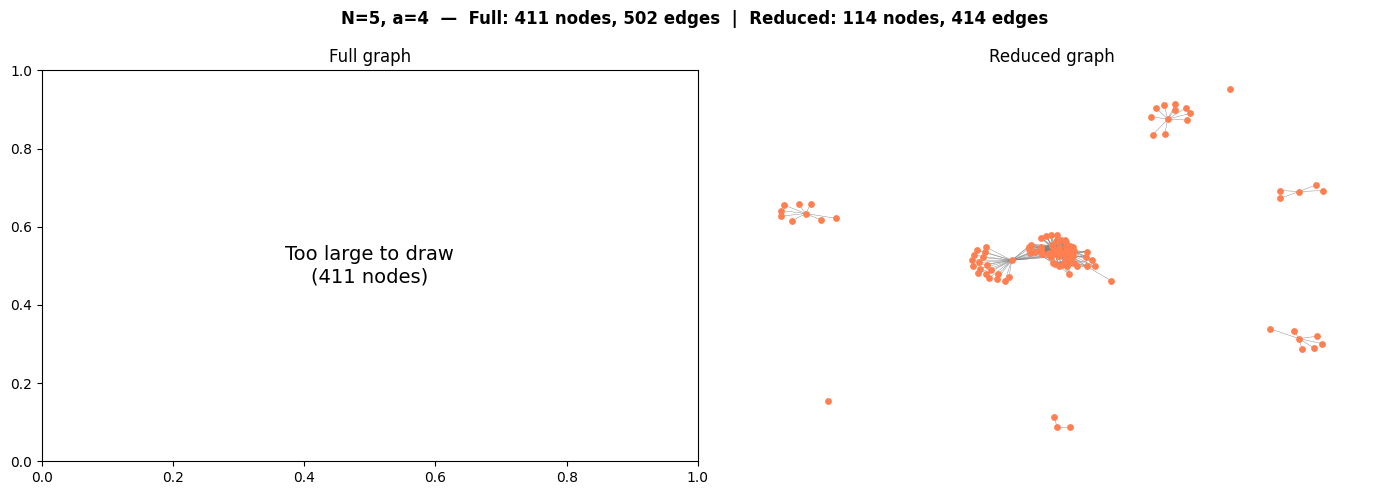

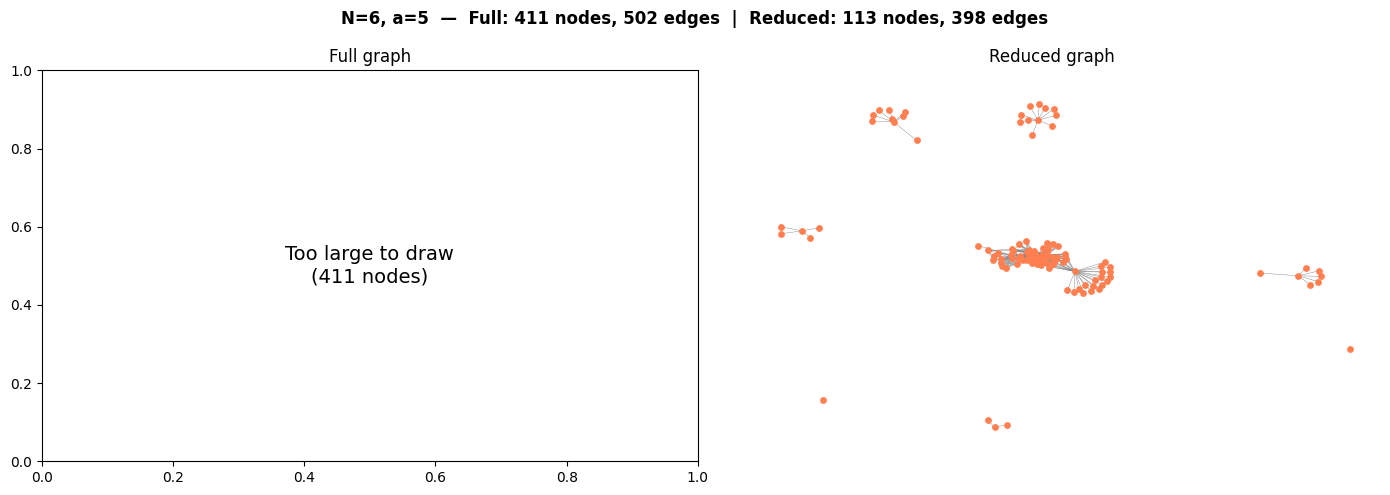

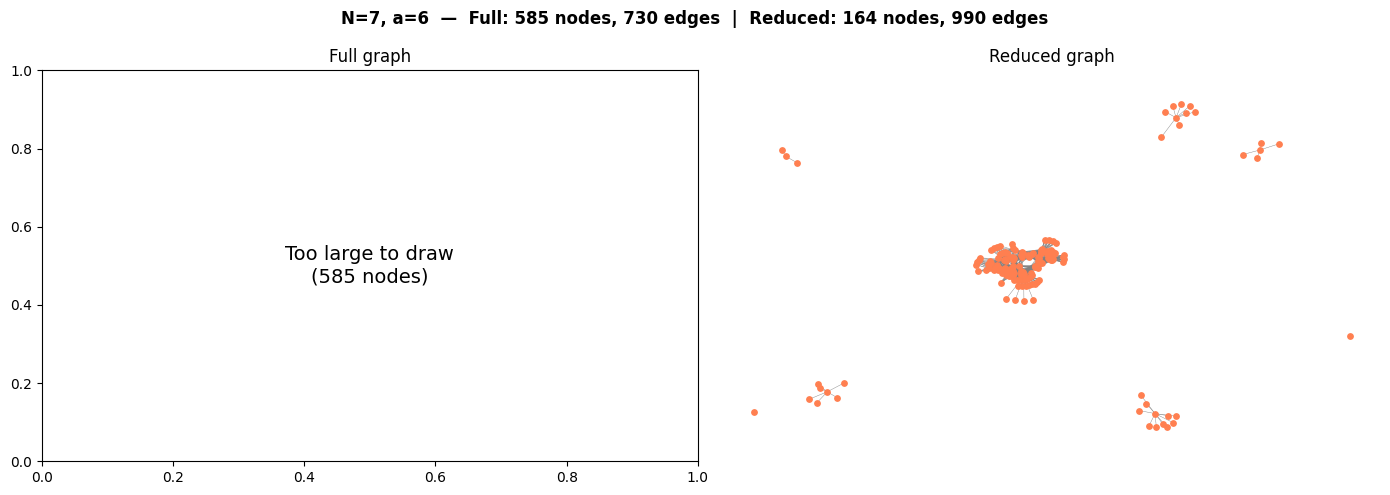

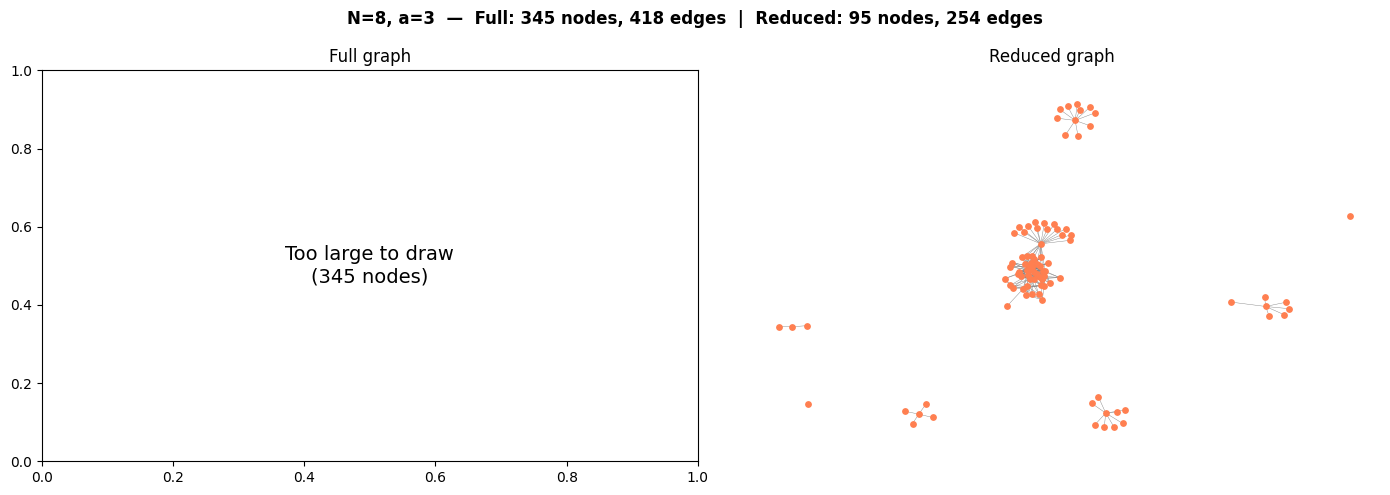

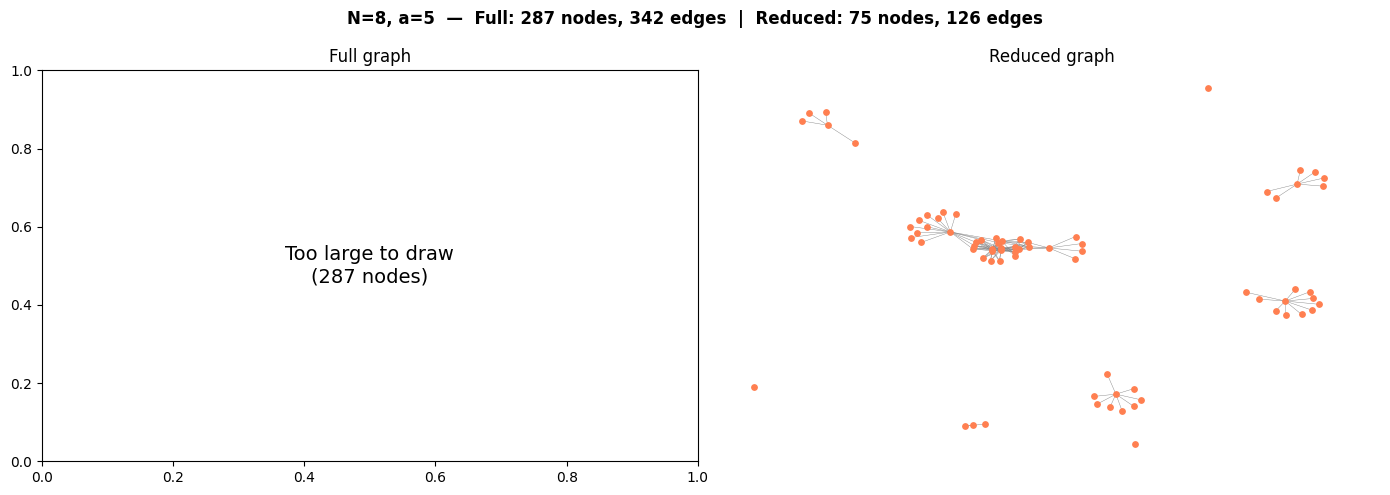

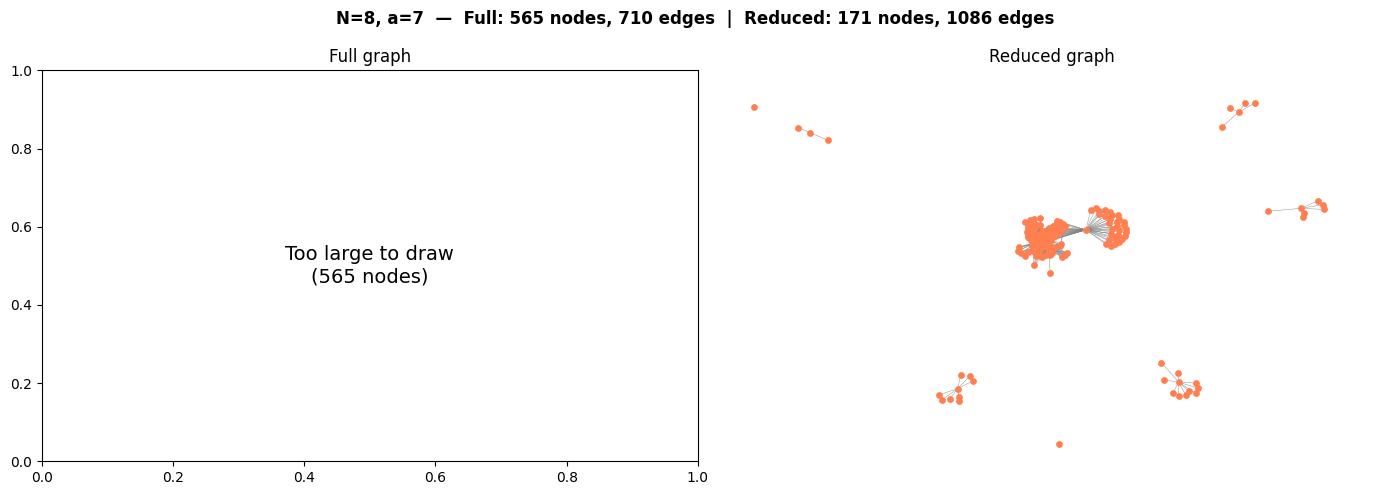

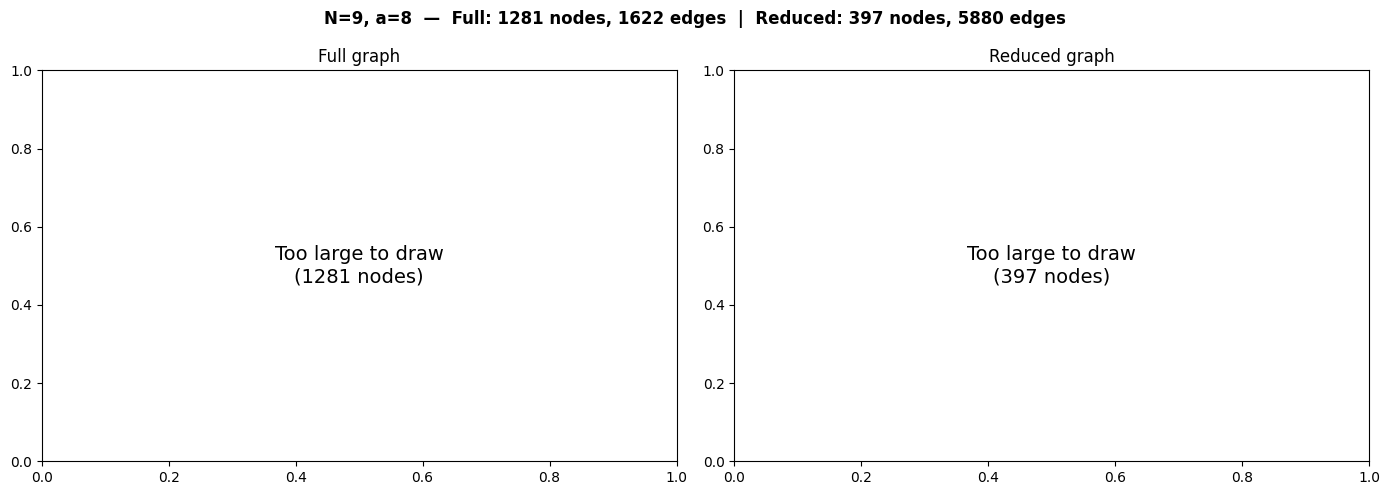

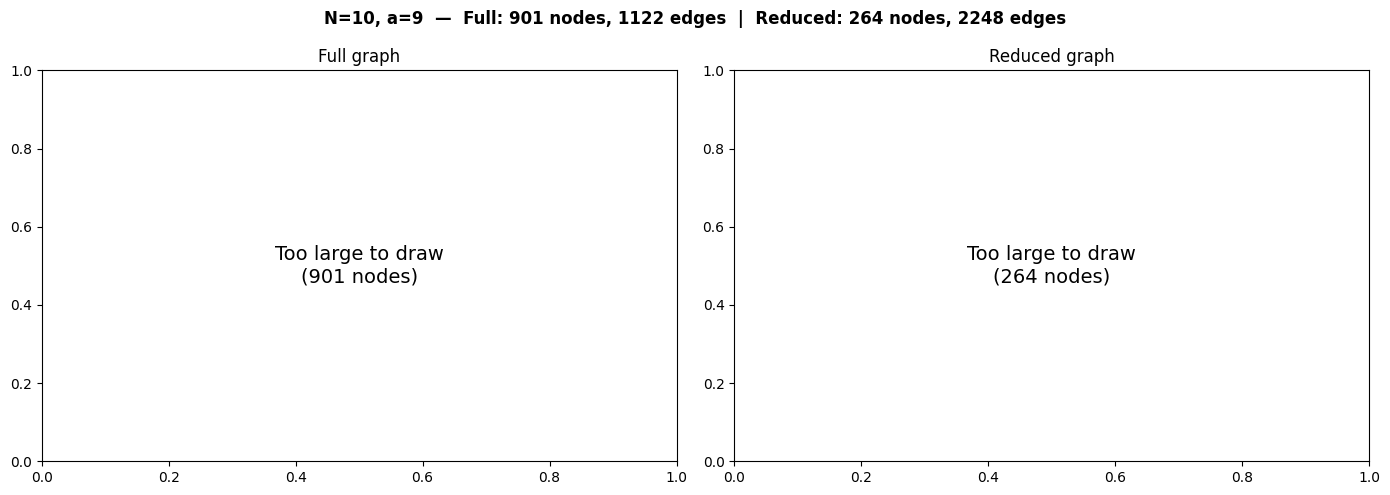

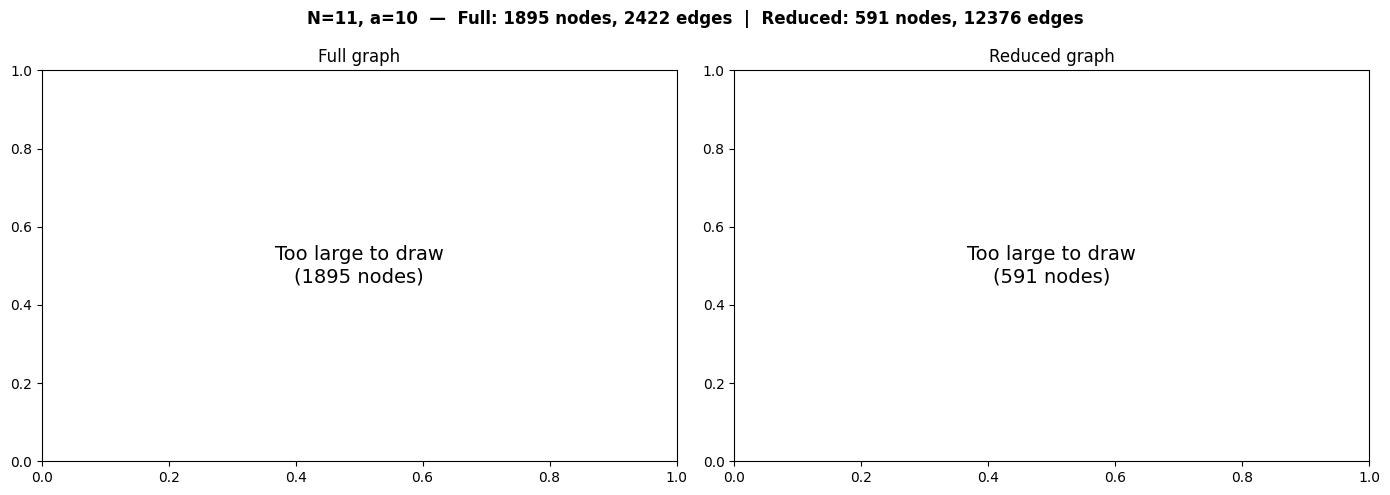

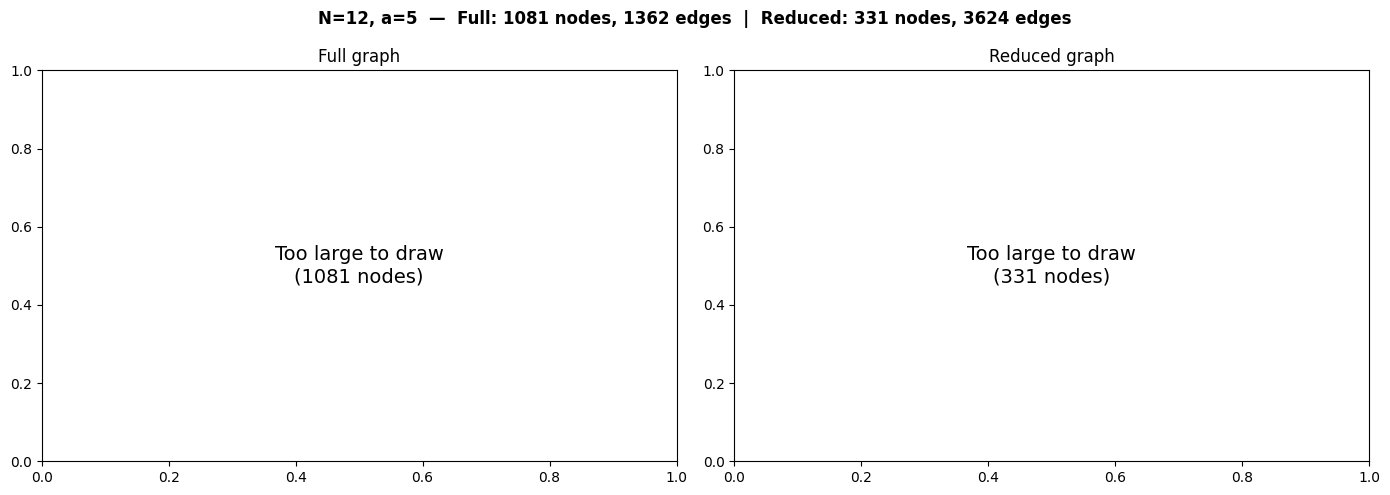

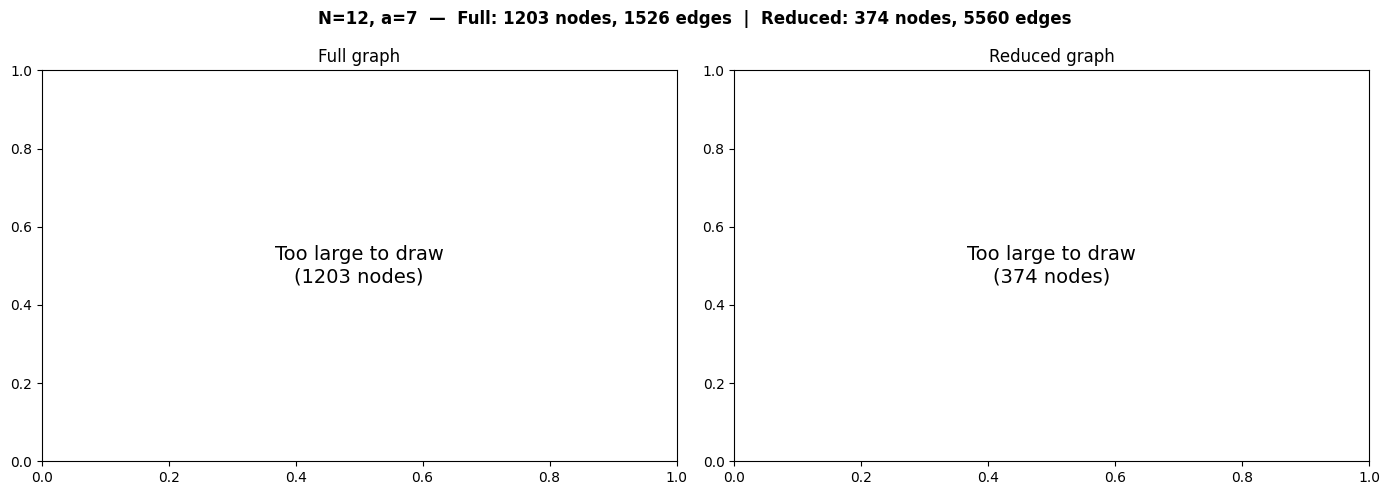

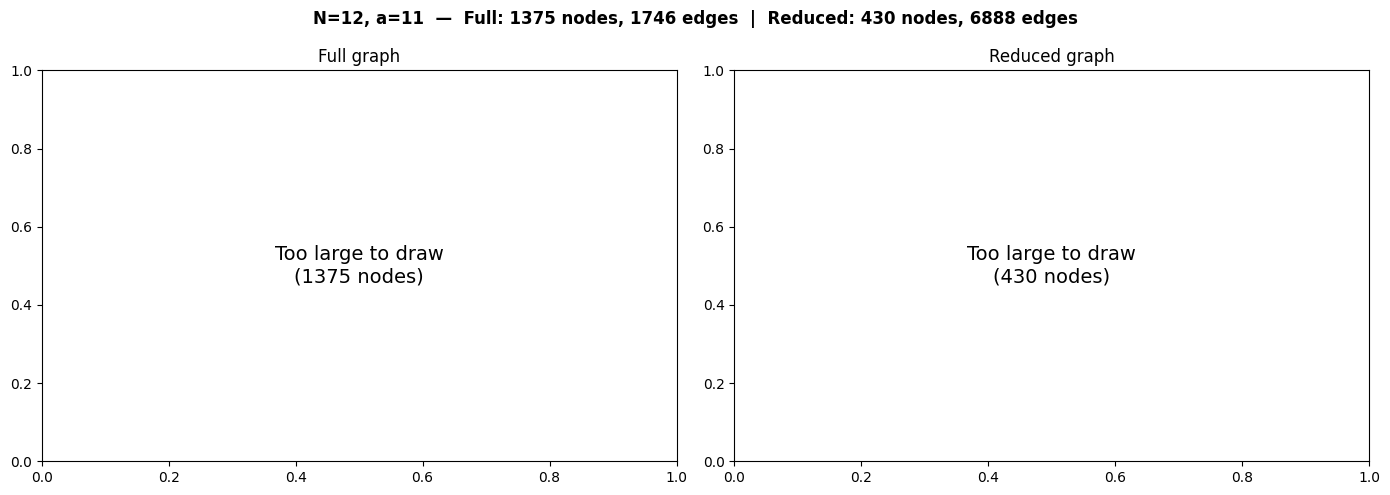

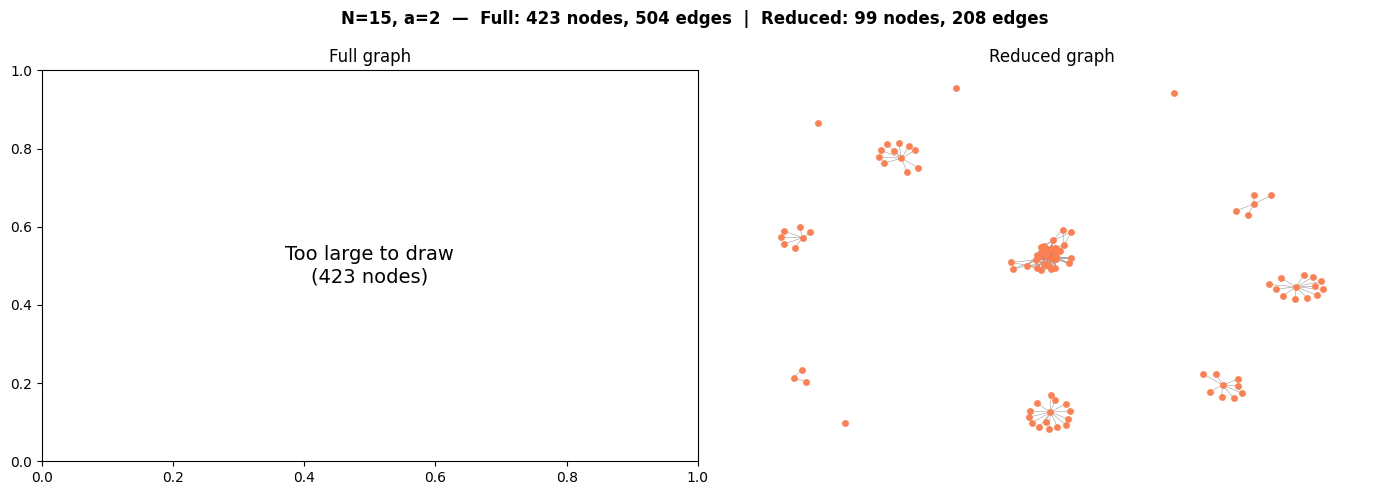

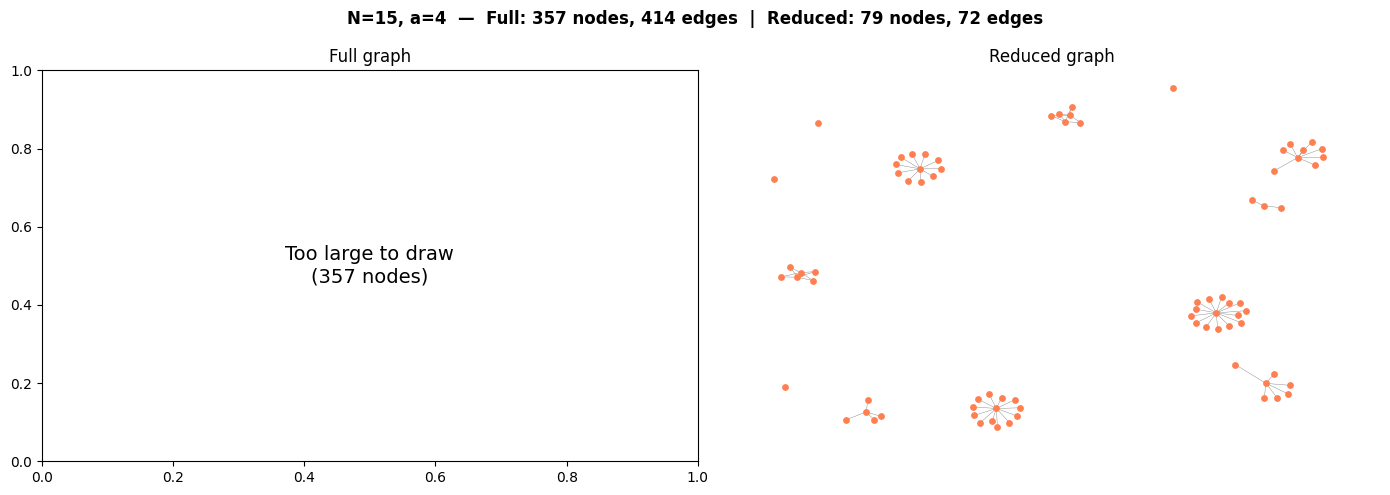

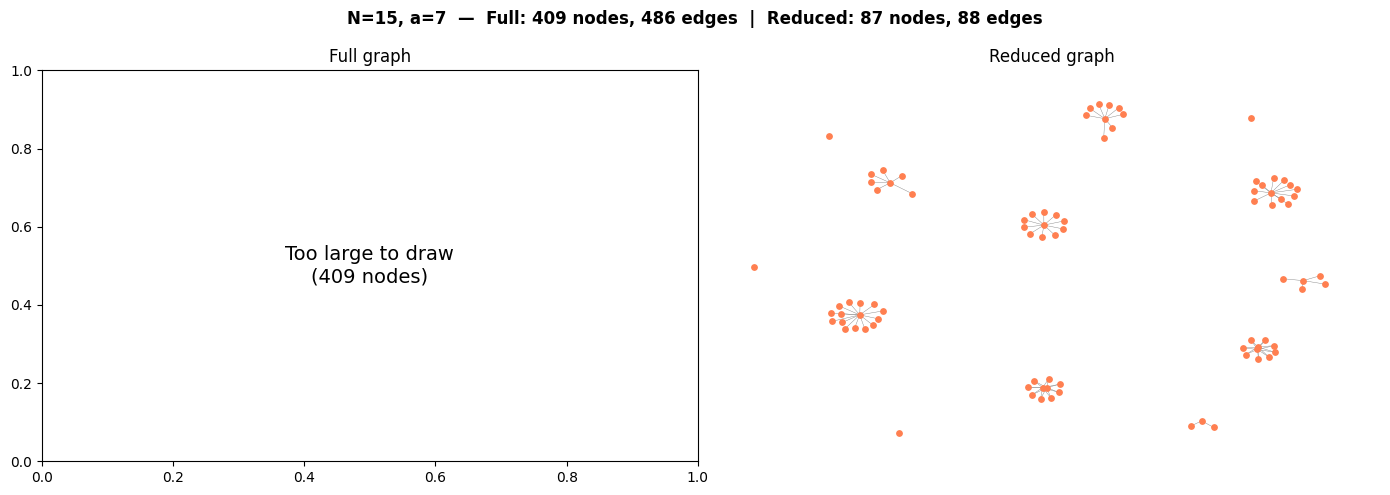

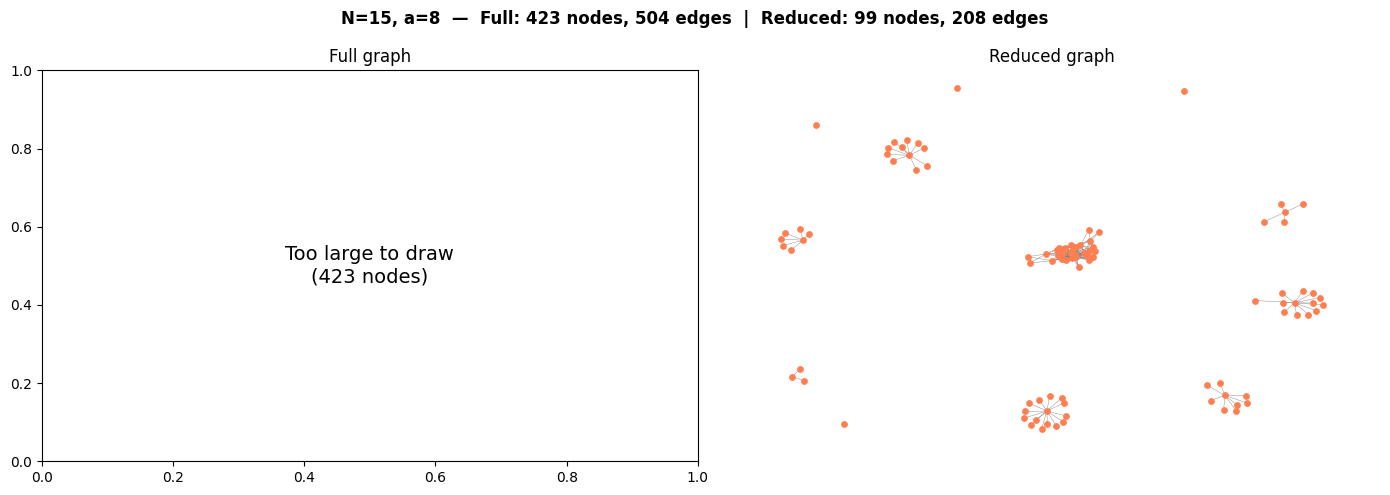

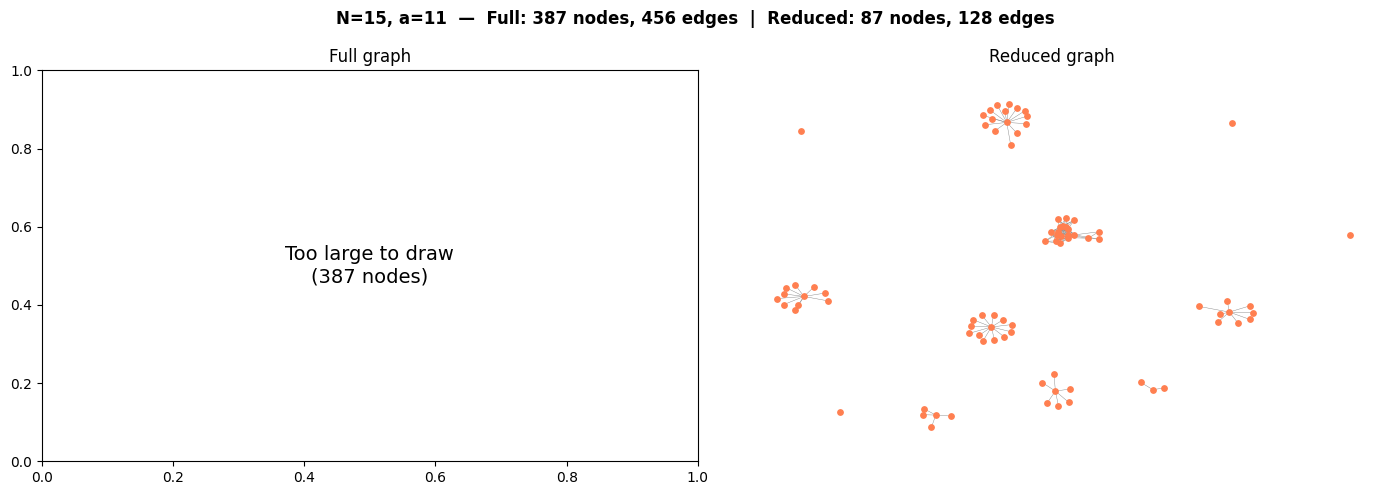

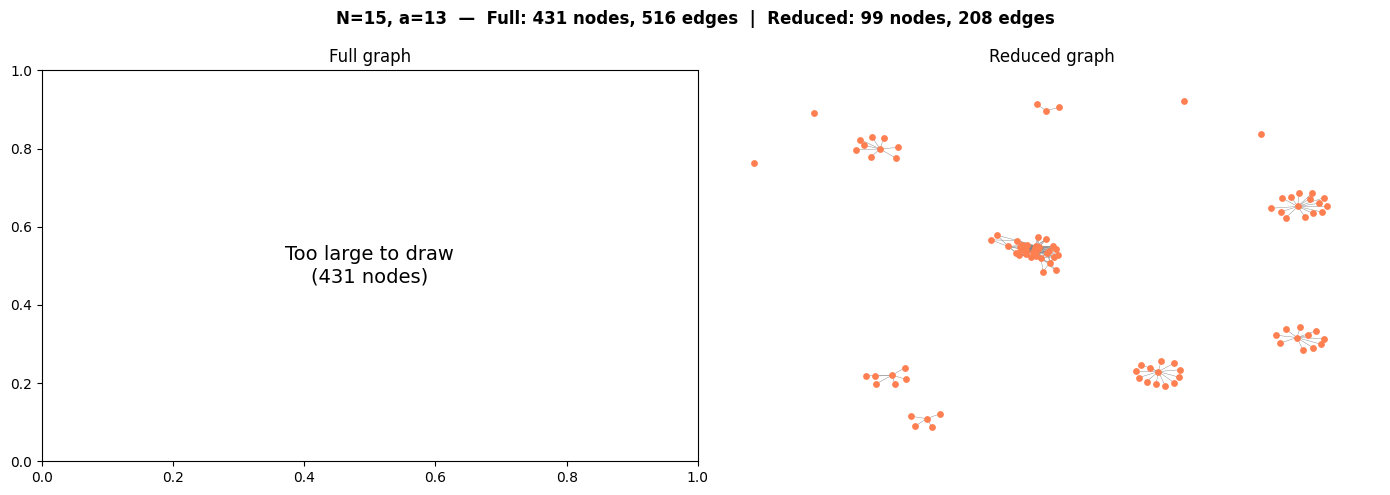

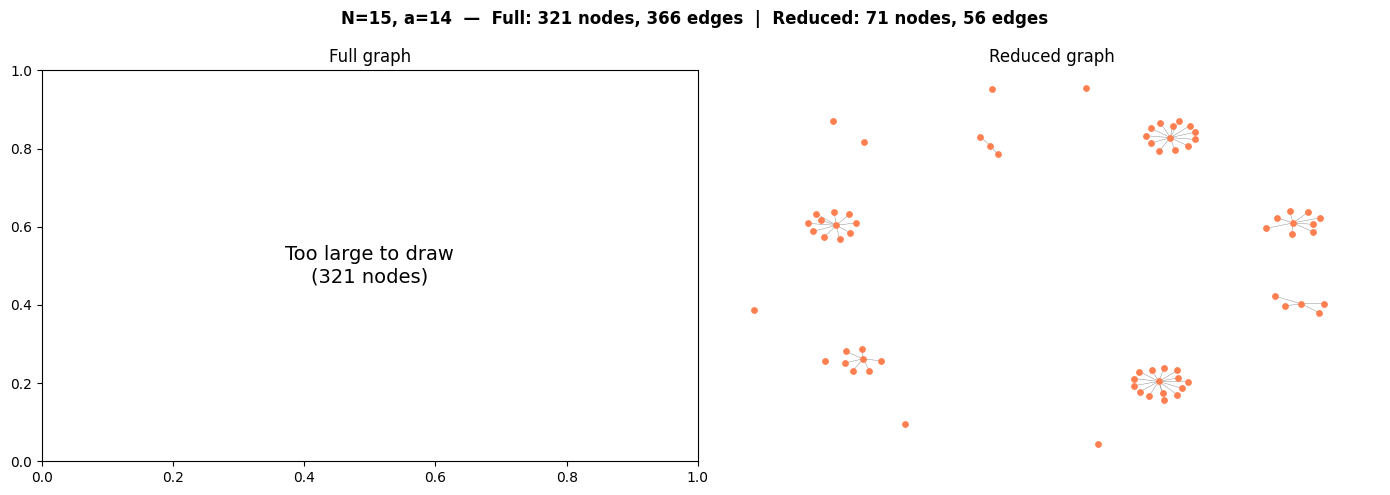

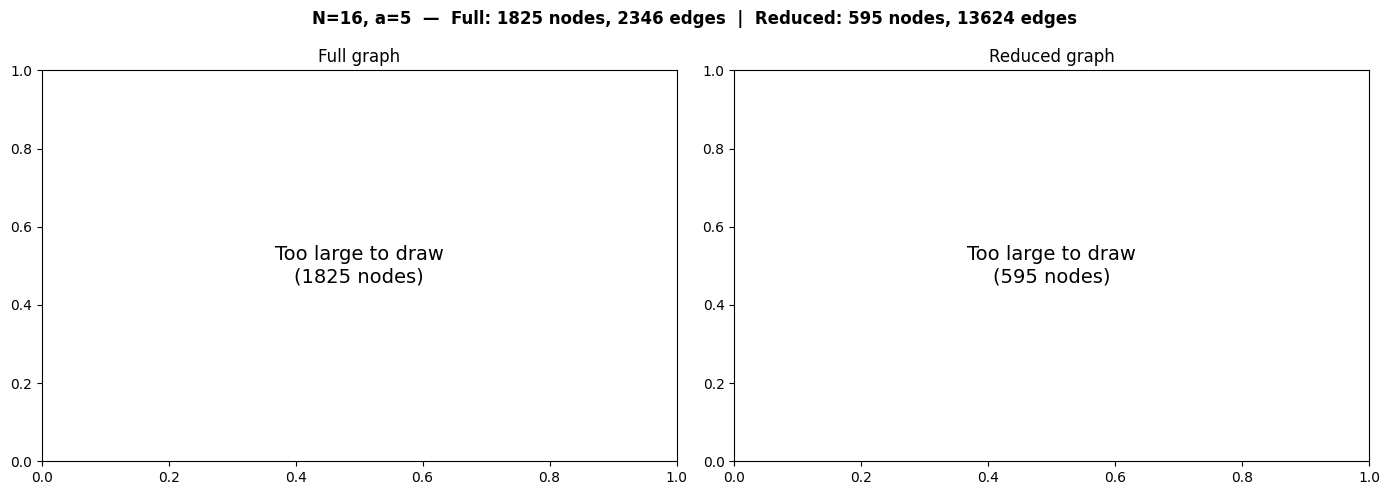

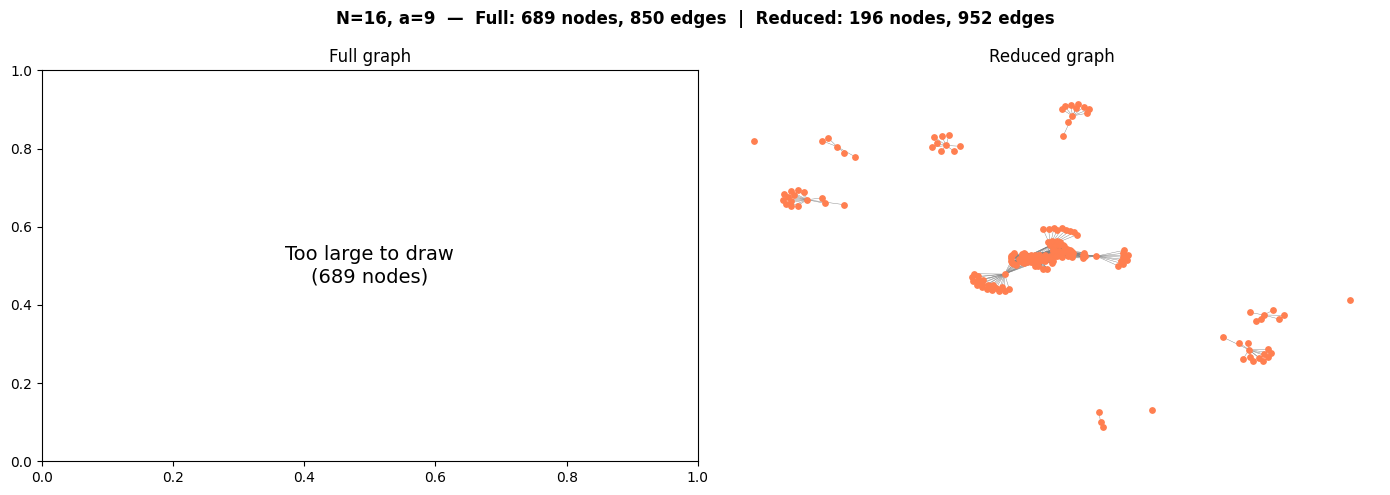

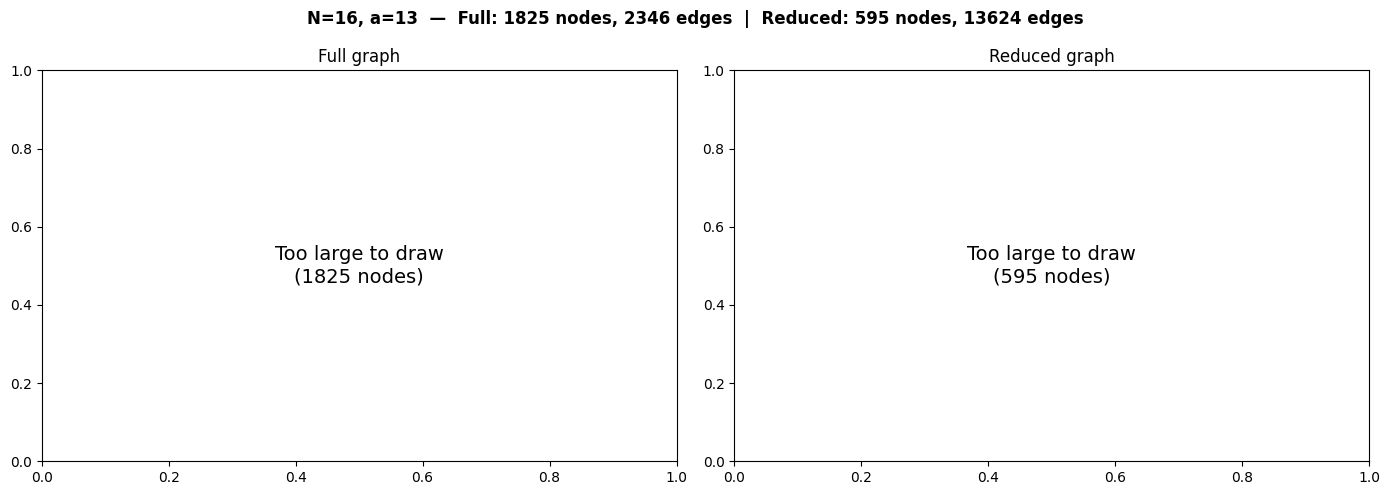

In [37]:
import matplotlib.pyplot as plt

# Sort by (N, a) for a consistent order
sorted_keys = sorted(all_graphs.keys())

for (N_val, a_val) in sorted_keys:
    graphs = all_graphs[(N_val, a_val)]
    G_full = graphs["full"]
    G_reduced = graphs["reduced"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"N={N_val}, a={a_val}  —  Full: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges  |  "
                 f"Reduced: {G_reduced.number_of_nodes()} nodes, {G_reduced.number_of_edges()} edges",
                 fontsize=12, fontweight='bold')

    # Full graph
    ax = axes[0]
    ax.set_title("Full graph")
    if G_full.number_of_nodes() <= 200:
        pos_f = nx.spring_layout(G_full, seed=42)
        nx.draw(G_full, pos_f, ax=ax, node_size=15, width=0.3, node_color="steelblue", edge_color="gray")
    else:
        ax.text(0.5, 0.5, f"Too large to draw\n({G_full.number_of_nodes()} nodes)",
                ha='center', va='center', transform=ax.transAxes, fontsize=14)

    # Reduced graph
    ax = axes[1]
    ax.set_title("Reduced graph")
    if G_reduced.number_of_nodes() <= 200:
        pos_r = nx.spring_layout(G_reduced, seed=42)
        nx.draw(G_reduced, pos_r, ax=ax, node_size=15, width=0.3, node_color="coral", edge_color="gray")
    else:
        ax.text(0.5, 0.5, f"Too large to draw\n({G_reduced.number_of_nodes()} nodes)",
                ha='center', va='center', transform=ax.transAxes, fontsize=14)

    plt.tight_layout()
    plt.show()

In [40]:
# Check node indexing for full and reduced graphs
for (N_val, a_val) in sorted(all_graphs.keys())[:5]:
    for label in ("full", "reduced"):
        G = all_graphs[(N_val, a_val)][label]
        nodes = sorted(G.nodes())
        n = G.number_of_nodes()
        if n == 0:
            print(f"N={N_val}, a={a_val} ({label:>7}): empty graph")
            continue
        expected = list(range(n))
        is_standard = (nodes == expected)
        print(f"N={N_val}, a={a_val} ({label:>7}): {n} nodes, min={nodes[0]}, max={nodes[-1]}, "
              f"contiguous 0..{n-1}? {is_standard}")


N=3, a=2 (   full): 135 nodes, min=0, max=134, contiguous 0..134? True
N=3, a=2 (reduced): 35 nodes, min=6, max=134, contiguous 0..34? False
N=4, a=3 (   full): 95 nodes, min=0, max=94, contiguous 0..94? True
N=4, a=3 (reduced): 23 nodes, min=6, max=94, contiguous 0..22? False
N=5, a=2 (   full): 825 nodes, min=0, max=824, contiguous 0..824? True
N=5, a=2 (reduced): 247 nodes, min=10, max=824, contiguous 0..246? False
N=5, a=3 (   full): 825 nodes, min=0, max=824, contiguous 0..824? True
N=5, a=3 (reduced): 247 nodes, min=10, max=824, contiguous 0..246? False
N=5, a=4 (   full): 411 nodes, min=0, max=410, contiguous 0..410? True
N=5, a=4 (reduced): 114 nodes, min=10, max=410, contiguous 0..113? False


Loaded: shor_N15_a8.pkl
  Nodes: 423, Edges: 504
  Node labels (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


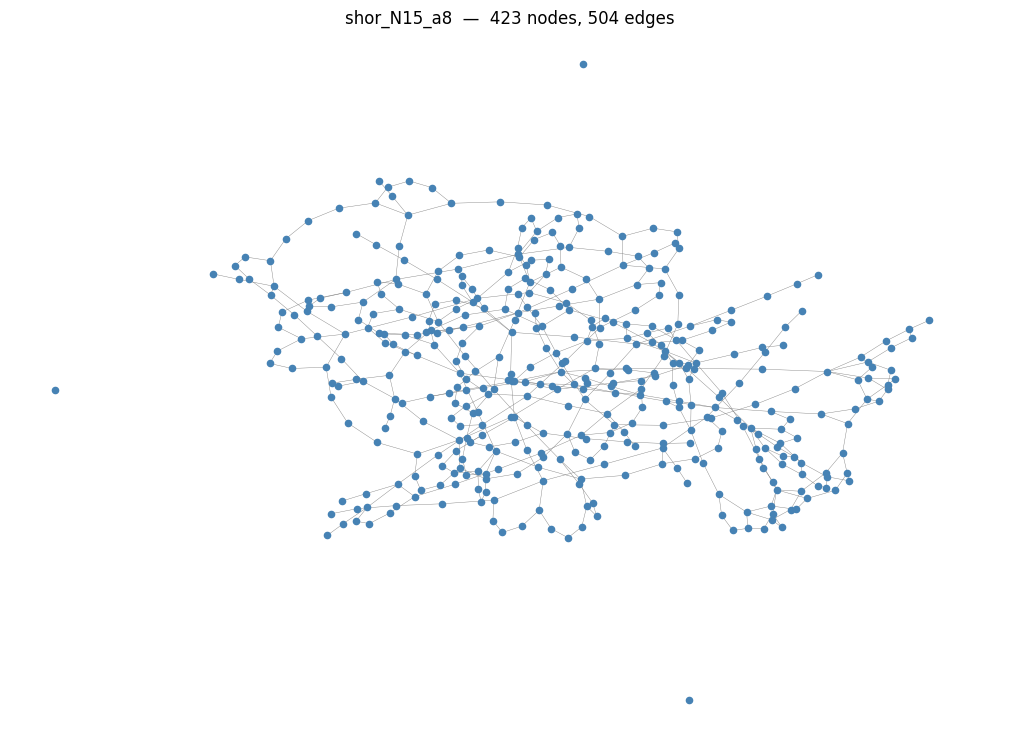

In [56]:
import pickle, pathlib, re
from optimization_script import run_optimization
#Load the functions for linear rank width 
from rank_width import linear_rank_width, lrw_of_ordering
# Load the functions for linear rank width SA
from rank_width_sa import linear_rank_width_sa
# Load the functions for path_clustering
from path_clustering import path_clustering_lrw


db_path = pathlib.Path("shor_graph_database/full")

def _sort_key(p):
    """Extract (N, a) numerically from filenames like shor_N3_a2.pkl."""
    m = re.search(r'N(\d+)_a(\d+)', p.stem)
    return (int(m.group(1)), int(m.group(2))) if m else (0, 0)

pkl_file = sorted(db_path.glob("*.pkl"), key=_sort_key)[14]

with open(pkl_file, "rb") as f:
    G_sample = pickle.load(f)

print(f"Loaded: {pkl_file.name}")
print(f"  Nodes: {G_sample.number_of_nodes()}, Edges: {G_sample.number_of_edges()}")
print(f"  Node labels (first 20): {sorted(G_sample.nodes())[:20]}")

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_sample, seed=42)
nx.draw(G_sample, pos, node_size=20, width=0.3, node_color="steelblue", edge_color="gray")
plt.title(f"{pkl_file.stem}  —  {G_sample.number_of_nodes()} nodes, {G_sample.number_of_edges()} edges")
plt.show()
